<div style='text-align: center; border: 2px solid #2ca02c; padding: 30px; border-radius: 10px; background-color: #f7fdf7;'>
  <h1 style='color: #2ca02c; font-size: 2.5em; margin-bottom: 0.2em;'>Mutual Fund Performance Analytics</h1>
  <h2 style='color: #555; font-size: 1.8em; margin-top: 0;'>Exploratory & Quantitative Risk Report</h2>
  <hr style='border: 1px solid #2ca02c; width: 60%; margin: 20px auto;'>
  <p style='font-size: 1.2em; font-weight: bold;'>Bluestock Fintech Capstone Project</p>
  <p style='font-size: 1.1em;'><strong>Author:</strong> Aditya Verma</p>
  <p style='font-size: 1.1em;'><strong>Date:</strong> June 2026</p>
  <br>
  <div style='text-align: left; display: inline-block; padding: 15px; border: 1px solid #ccc; border-radius: 5px; background-color: #ffffff;'>
    <h3 style='margin-top: 0; color: #333;'>Core Objectives & Ratios Calculated:</h3>
    <ul style='margin-bottom: 0;'>
      <li><strong>Returns Analysis:</strong> Daily Log/Simple Returns, CAGR (1Y, 3Y, 5Y/Max)</li>
      <li><strong>Risk-Adjusted Ratios:</strong> Sharpe Ratio, Sortino Ratio (Downside Deviation)</li>
      <li><strong>Market Risk Exposure:</strong> Alpha & Beta (Scipy Linear Regression)</li>
      <li><strong>Drawdown Profiles:</strong> Rolling Max, Maximum Drawdown Peak/Trough Dates</li>
      <li><strong>Rankings & Metrics:</strong> Multi-Criteria Scorecard (A+ to C), Tracking Error</li>
    </ul>
  </div>
</div>

---


## 📌 Table of Contents

1. [Setup and Data Loading](#setup)
2. [Data Validation & Quality Checks](#validation)
3. [Daily Return Analysis & Normality Check](#daily-returns)
4. [CAGR Analysis (1Y, 3Y, 5Y/Max)](#cagr)
5. [Sharpe Ratio Performance (Rf = 6.5%)](#sharpe)
6. [Sortino Ratio Performance (Downside Volatility)](#sortino)
7. [Alpha & Beta Risk Analysis (Nifty 100 Regression)](#alpha-beta)
8. [Maximum Drawdown Peak & Trough Profiling](#drawdown)
9. [Composite Fund Scorecard & Qualitative Grading](#scorecard)
10. [Benchmark Comparison & Tracking Error Analytics](#benchmark)
11. [Dynamic Performance Insights](#insights)
12. [Conclusion & Portfolio Allocations](#conclusion)

---


<a id='setup'></a>
## ⚙️ 1. Setup and Data Loading

First, we import the necessary libraries, configure visualization styles, and load the processed datasets immediately converting date columns.


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown

# Configuration and style setups
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14,
    'figure.dpi': 150
})

processed_dir = r"data/processed"
charts_dir = r"reports/charts"
os.makedirs(charts_dir, exist_ok=True)

# Load cleaned datasets
df_master = pd.read_csv(os.path.join(processed_dir, "clean_fund_master.csv"))
df_nav = pd.read_csv(os.path.join(processed_dir, "clean_nav_history.csv"))
df_perf = pd.read_csv(os.path.join(processed_dir, "clean_scheme_performance.csv"))
df_bench = pd.read_csv(os.path.join(processed_dir, "clean_benchmark_indices.csv"))

# Parse Date columns immediately to datetime
if 'date' in df_nav.columns:
    df_nav['date'] = pd.to_datetime(df_nav['date'])
if 'date' in df_bench.columns:
    df_bench['date'] = pd.to_datetime(df_bench['date'])

print("All datasets loaded successfully and date columns parsed.")


All datasets loaded successfully and date columns parsed.


<a id='validation'></a>
## 🔬 2. Data Validation & Quality Checks

We inspect missing value profiles, search for duplicate observations, and check loaded shapes to confirm full data integrity before executing computations.


In [7]:
validation_errors = 0
datasets_to_check = {
    'Fund Master': df_master,
    'NAV History': df_nav,
    'Scheme Performance': df_perf,
    'Benchmark Indices': df_bench
}

for name, df in datasets_to_check.items():
    print(f"Validating {name}...")
    print(f"  Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # Check duplicates
    dups = df.duplicated().sum()
    print(f"  Duplicate rows: {dups}")
    if dups > 0:
        validation_errors += 1
        
    # Check missing values
    null_cols = df.isna().sum()
    total_nulls = null_cols.sum()
    print(f"  Missing values: {total_nulls}")
    if total_nulls > 0:
        print("  Missing values by column:")
        print(null_cols[null_cols > 0])
        
print("\nValidation process complete.")
if validation_errors == 0:
    print("SUCCESS: No duplicate rows detected across all datasets.")
else:
    print("WARNING: Some data quality checks failed.")


Validating Fund Master...
  Shape: 40 rows, 15 columns
  Duplicate rows: 0
  Missing values: 0
Validating NAV History...
  Shape: 46000 rows, 3 columns
  Duplicate rows: 0
  Missing values: 0
Validating Scheme Performance...
  Shape: 40 rows, 20 columns
  Duplicate rows: 0
  Missing values: 0
Validating Benchmark Indices...
  Shape: 8050 rows, 3 columns
  Duplicate rows: 0
  Missing values: 0

Validation process complete.
SUCCESS: No duplicate rows detected across all datasets.


<a id='daily-returns'></a>
## 📈 3. Daily Return Analysis & Normality Check

We compute daily returns for each scheme using the Net Asset Value (NAV) history:

$$R_{i,t} = \frac{NAV_{i,t}}{NAV_{i,t-1}} - 1$$

We group by `amfi_code` to ensure that returns are calculated within each fund series without overlap. We also output daily returns and generate normality diagnostics (KDE & Q-Q Plot).


Verification: First return for all schemes is NaN: True
Total computed returns: 45960
Mean daily return: 0.000631
Std dev daily return: 0.010290
Min return: -5.810201%
Max return: 6.471309%
Exported daily returns successfully to daily_returns.csv


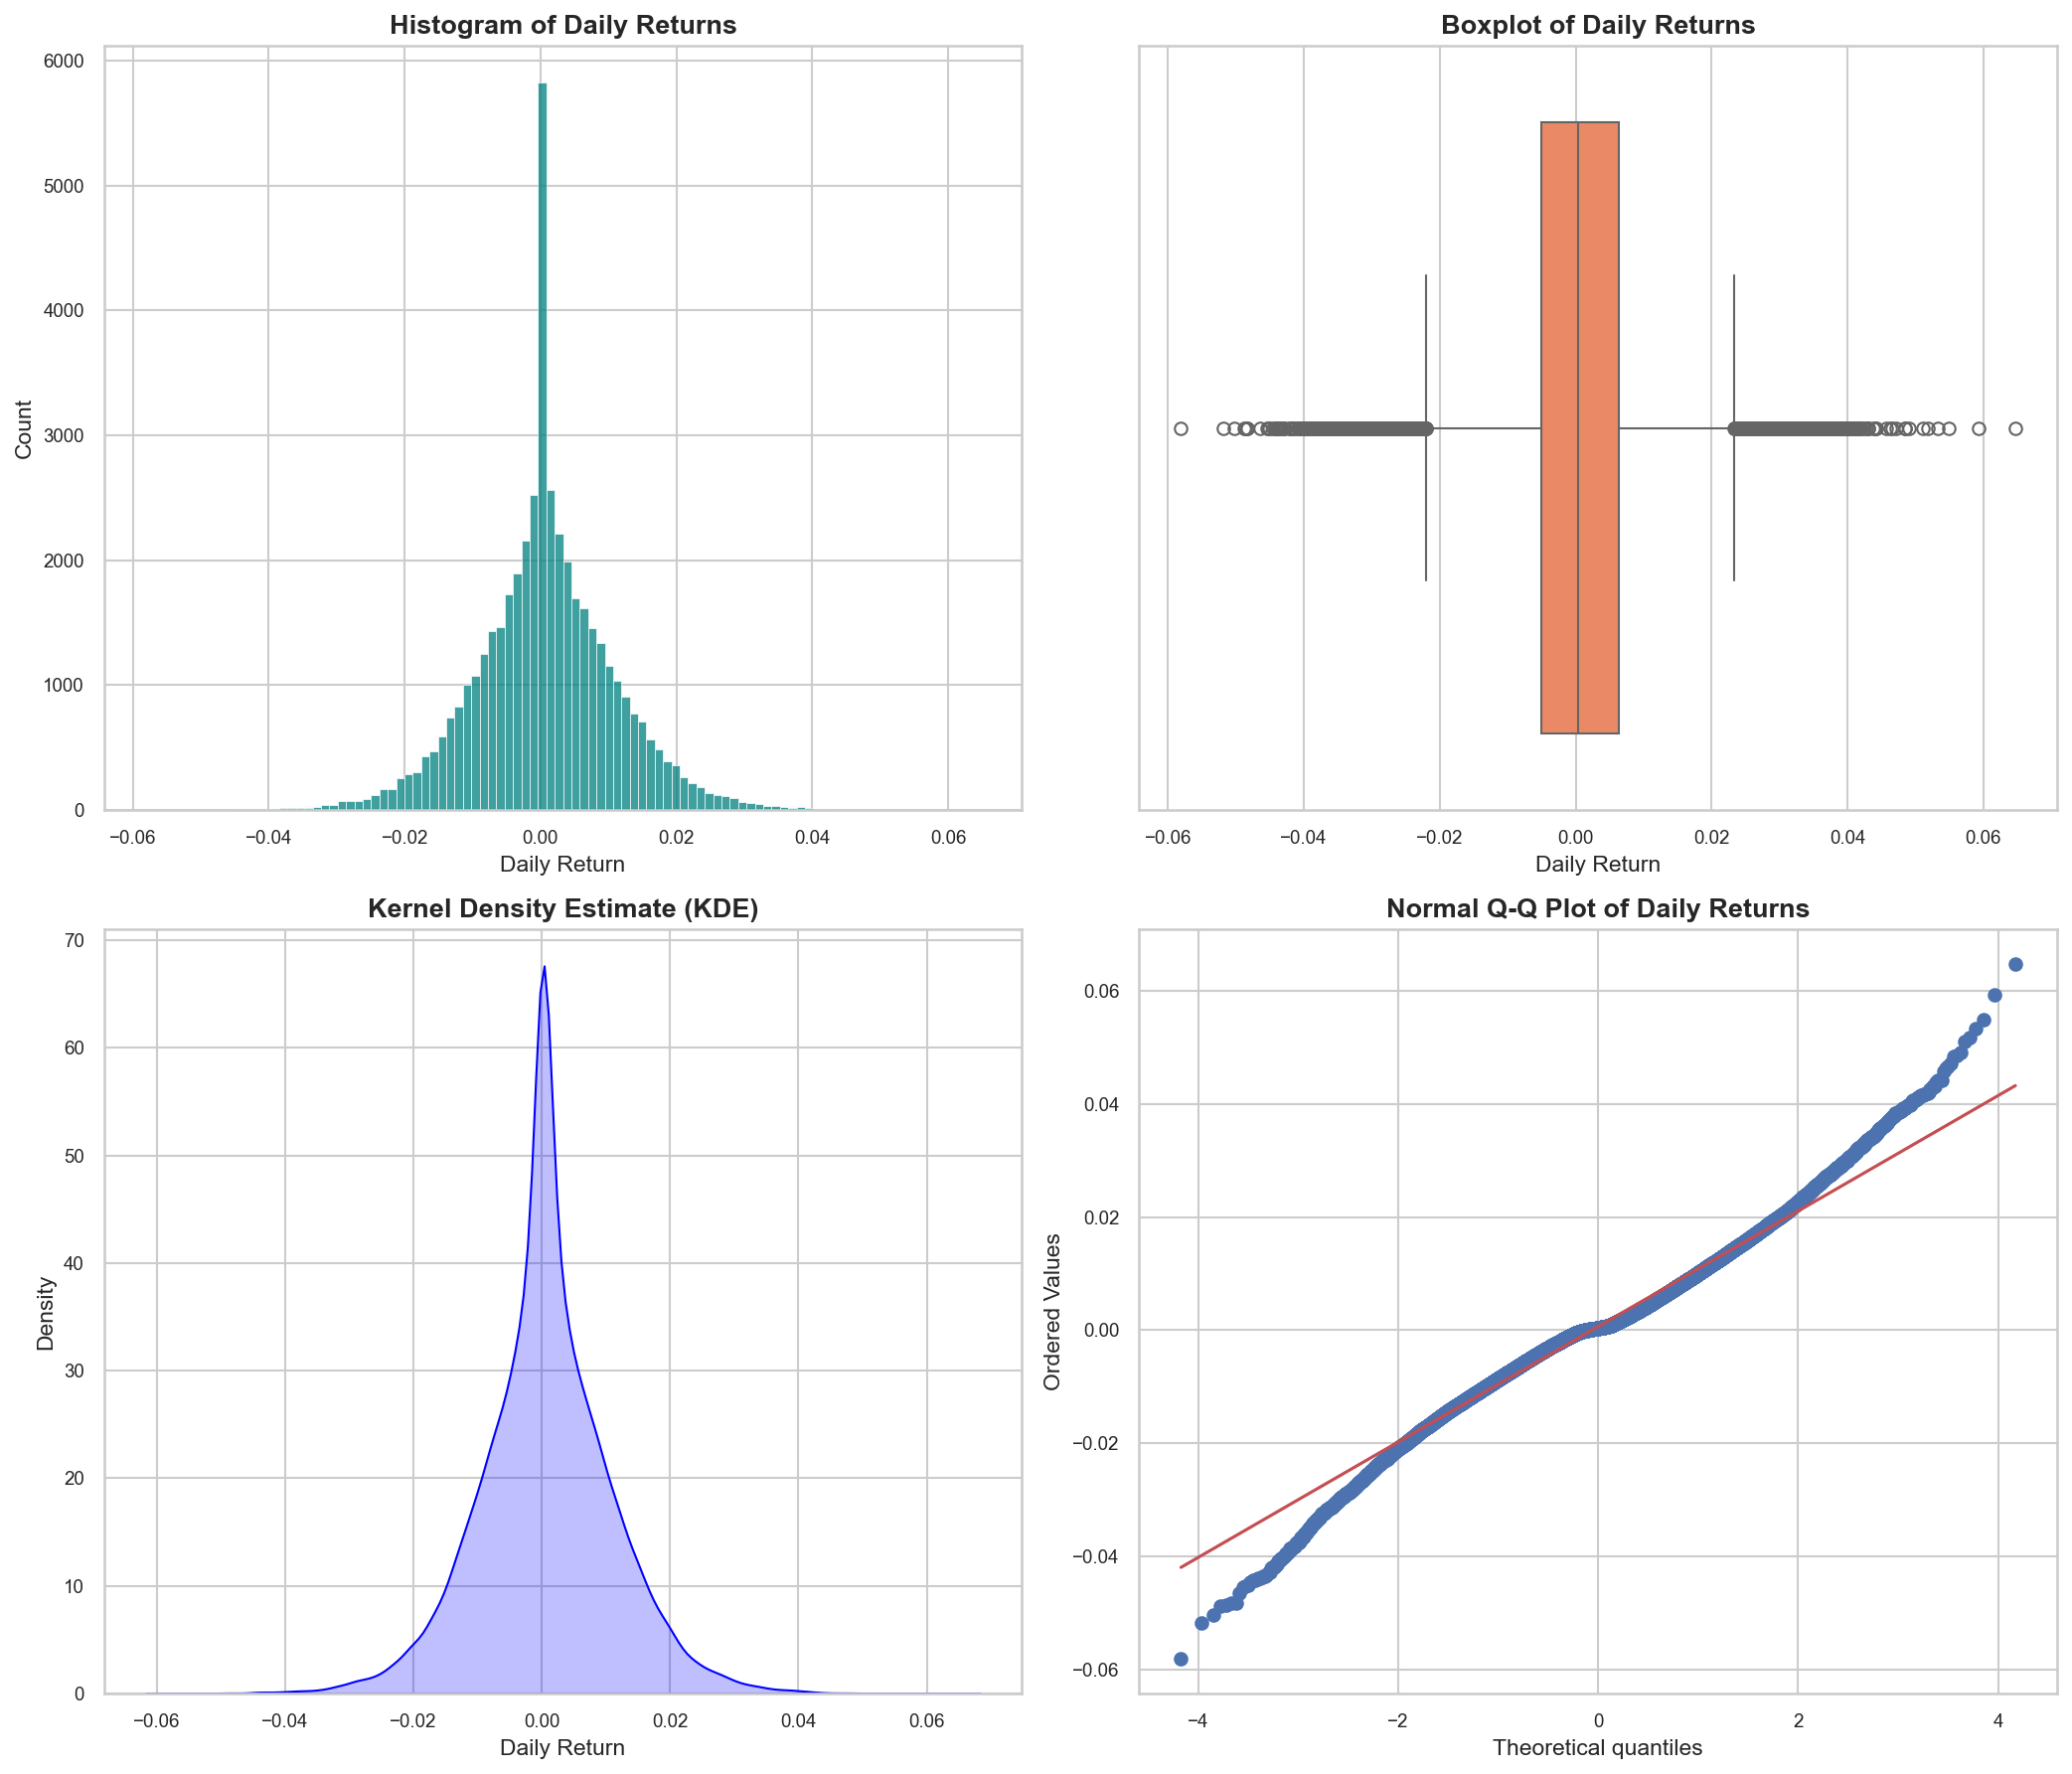

In [8]:
if not df_nav.empty and 'amfi_code' in df_nav.columns and 'nav' in df_nav.columns and 'date' in df_nav.columns:
    # Sort by scheme and date
    df_nav = df_nav.sort_values(by=['amfi_code', 'date'])
    
    # Compute daily return
    df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()
    
    # Validate first return is NaN
    first_returns = df_nav.groupby('amfi_code')['daily_return'].nth(0)
    all_nan_first = first_returns.isna().all()
    print(f"Verification: First return for all schemes is NaN: {all_nan_first}")
    
    # Check return distribution summaries
    valid_returns = df_nav['daily_return'].dropna()
    print(f"Total computed returns: {len(valid_returns)}")
    print(f"Mean daily return: {valid_returns.mean():.6f}")
    print(f"Std dev daily return: {valid_returns.std():.6f}")
    print(f"Min return: {valid_returns.min():.6%}")
    print(f"Max return: {valid_returns.max():.6%}")
    
    # Export returns file (rounded for Power BI)
    df_nav_export = df_nav[['date', 'amfi_code', 'nav', 'daily_return']].copy()
    df_nav_export['daily_return'] = df_nav_export['daily_return'].round(6)
    returns_export_path = "daily_returns.csv"
    df_nav_export.to_csv(returns_export_path, index=False)
    print(f"Exported daily returns successfully to {returns_export_path}")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Histogram
    sns.histplot(valid_returns, bins=100, kde=False, ax=axes[0,0], color='teal')
    axes[0,0].set_title("Histogram of Daily Returns", fontweight='bold')
    axes[0,0].set_xlabel("Daily Return")
    axes[0,0].set_ylabel("Count")
    
    # 2. Boxplot
    sns.boxplot(x=valid_returns, ax=axes[0,1], color='coral')
    axes[0,1].set_title("Boxplot of Daily Returns", fontweight='bold')
    axes[0,1].set_xlabel("Daily Return")
    
    # 3. Kernel Density Estimate (KDE)
    sns.kdeplot(valid_returns, ax=axes[1,0], color='blue', fill=True)
    axes[1,0].set_title("Kernel Density Estimate (KDE)", fontweight='bold')
    axes[1,0].set_xlabel("Daily Return")
    
    # 4. Q-Q Plot
    stats.probplot(valid_returns, dist="norm", plot=axes[1,1])
    axes[1,1].set_title("Normal Q-Q Plot of Daily Returns", fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "daily_returns_distribution.png"), dpi=300)
    plt.show()
else:
    print("Warning: df_nav is empty or missing columns. Skipping return calculation.")


### 🔬 Normality Diagnostics & Financial Implications

**Do Daily Returns Follow a Normal Distribution?**
Based on the **KDE Plot** and **Q-Q Plot**, the daily returns of mutual funds do **not** follow a normal distribution. While the center of the distribution shows a peak near zero, we observe **fat tails (leptokurtosis)** and extreme values (outliers) that deviate significantly from the red normal line on the Q-Q plot. This is a classic characteristic of financial asset returns.

**Why This Matters in Finance:**
1.  **Underestimation of Extreme Risk:** Standard risk measures like Value-at-Risk (VaR) or Sharpe ratios assume normality. If returns have fat tails, extreme negative returns (market crashes) will occur with a much higher probability than predicted by a normal distribution.
2.  **Portfolio Diversification:** Asset correlations during extreme market drawdowns tend to shift. Assuming normality can lead to poor diversification and capital overallocation during stress periods.


<a id='cagr'></a>
## 📈 4. CAGR Analysis (1Y, 3Y, 5Y/Max)

We calculate the Compound Annual Growth Rate (CAGR) using Net Asset Value endpoints over 1 Year, 3 Year, and 5 Year (falling back to the maximum available historical period when the series is shorter than 5 years):

$$\text{CAGR} = \left( \frac{NAV_{\text{end}}}{NAV_{\text{start}}} \right)^{\frac{1}{\text{years}}} - 1$$

We also group schemes by sub_category/category to compare median performance across Large Cap, Mid Cap, Small Cap, Debt, and Hybrid classes.


Exported CAGR summary successfully to cagr_summary.csv


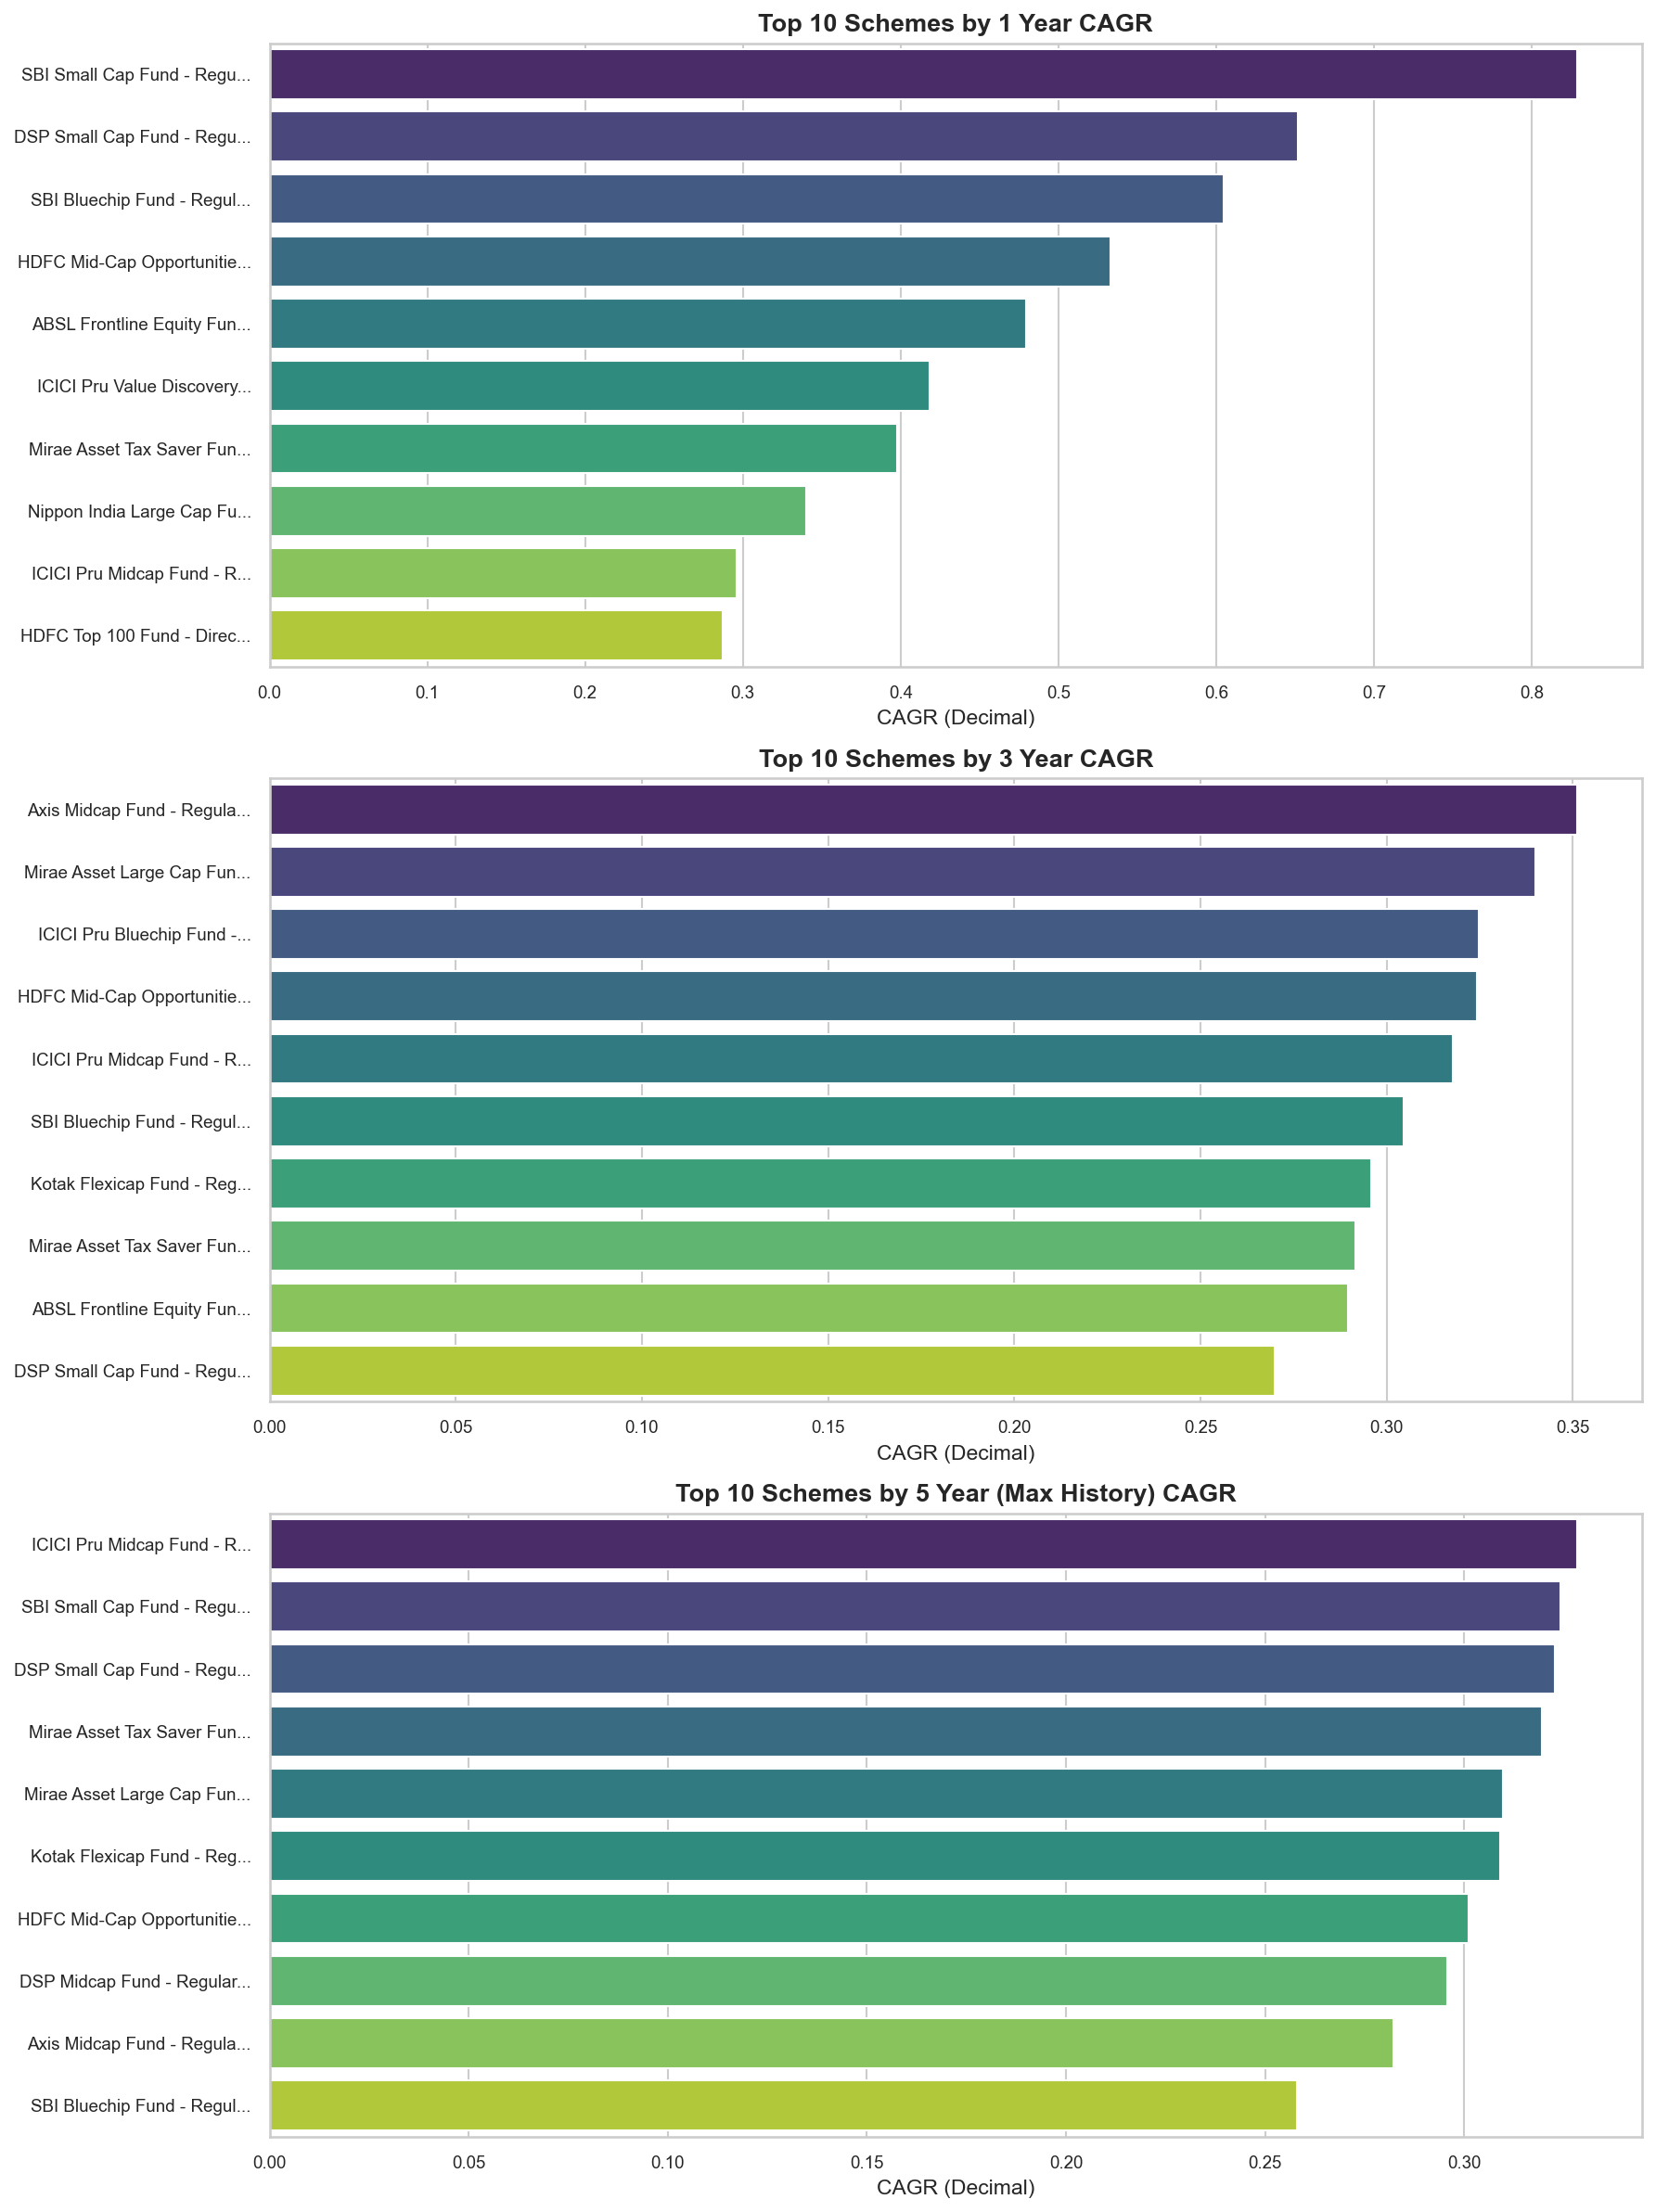

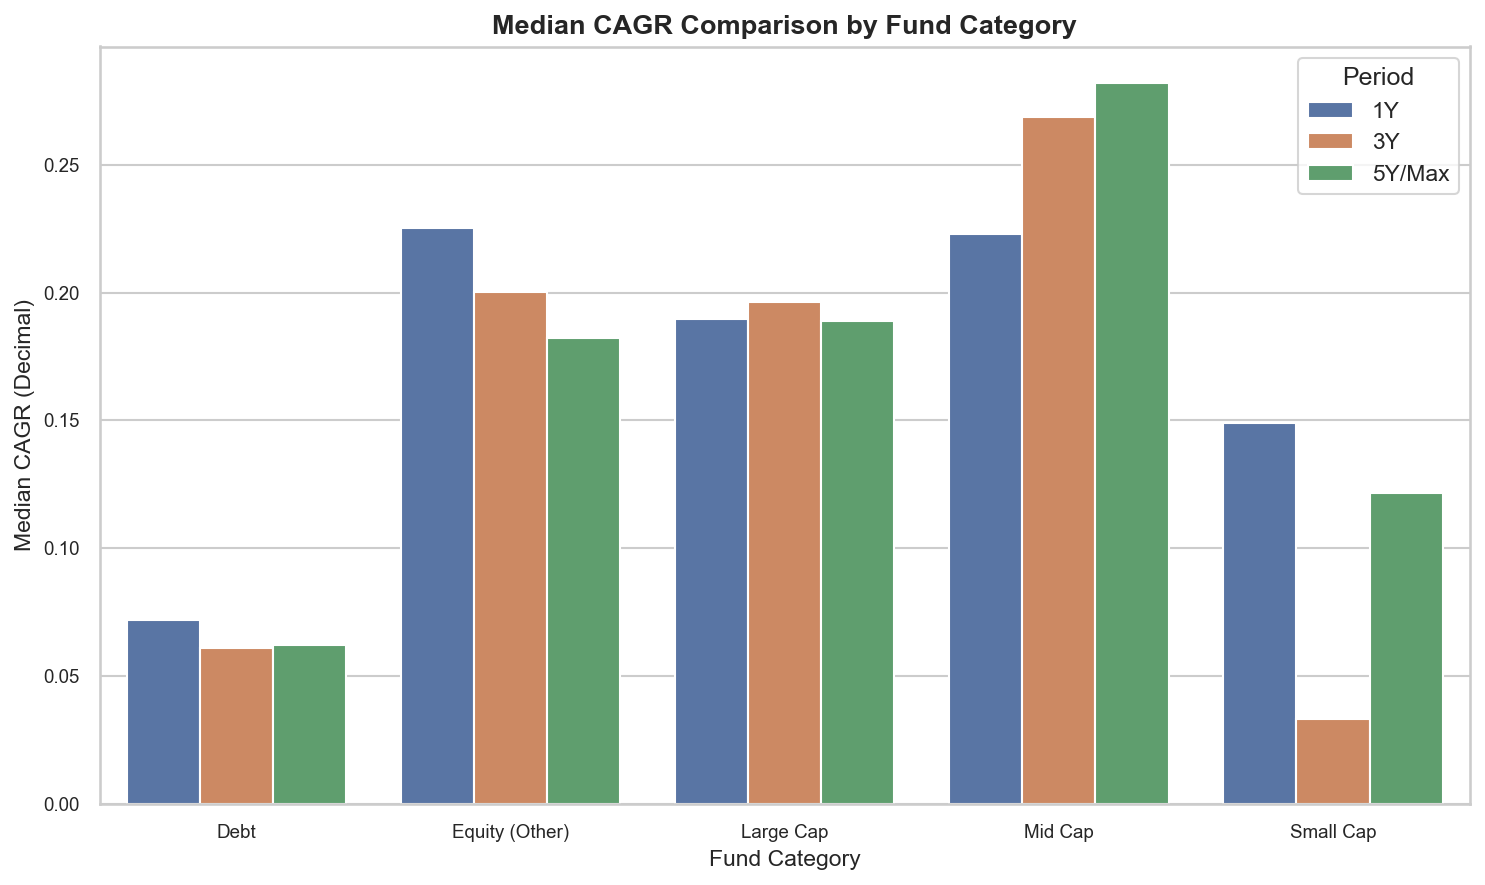

In [9]:
if not df_nav.empty and 'amfi_code' in df_nav.columns and 'nav' in df_nav.columns and 'date' in df_nav.columns:
    cagr_records = []
    
    for amfi, group in df_nav.groupby('amfi_code'):
        # Group is already sorted by date
        if len(group) < 2:
            continue
        latest_row = group.iloc[-1]
        latest_date = latest_row['date']
        nav_end = latest_row['nav']
        earliest_date = group['date'].min()
        
        # 1Y CAGR
        target_1y = latest_date - pd.DateOffset(years=1)
        row_1y = group.loc[(group['date'] - target_1y).abs().idxmin()]
        y1_years = (latest_date - row_1y['date']).days / 365.25
        cagr_1y = (nav_end / row_1y['nav'])**(1/y1_years) - 1 if y1_years > 0.1 else np.nan
        
        # 3Y CAGR
        target_3y = latest_date - pd.DateOffset(years=3)
        row_3y = group.loc[(group['date'] - target_3y).abs().idxmin()]
        y3_years = (latest_date - row_3y['date']).days / 365.25
        cagr_3y = (nav_end / row_3y['nav'])**(1/y3_years) - 1 if y3_years > 0.1 else np.nan
        
        # 5Y CAGR (falls back to earliest available)
        target_5y = latest_date - pd.DateOffset(years=5)
        start_date_5y = max(target_5y, earliest_date)
        row_5y = group.loc[(group['date'] - start_date_5y).abs().idxmin()]
        y5_years = (latest_date - row_5y['date']).days / 365.25
        cagr_5y = (nav_end / row_5y['nav'])**(1/y5_years) - 1 if y5_years > 0.1 else np.nan
        
        cagr_records.append({
            'amfi_code': amfi,
            'cagr_1y': cagr_1y,
            'cagr_3y': cagr_3y,
            'cagr_5y': cagr_5y
        })
        
    df_cagr = pd.DataFrame(cagr_records)
    df_cagr = df_master[['amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category']].merge(df_cagr, on='amfi_code', how='inner')
    
    # Round CAGR columns to 4 decimal places for CSV export
    df_cagr_export = df_cagr.copy()
    for col in ['cagr_1y', 'cagr_3y', 'cagr_5y']:
        df_cagr_export[col] = df_cagr_export[col].round(4)
    
    cagr_export_path = "cagr_summary.csv"
    df_cagr_export.to_csv(cagr_export_path, index=False)
    print(f"Exported CAGR summary successfully to {cagr_export_path}")
    
    # Truncate scheme names for visual elegance
    df_cagr['scheme_name_trunc'] = df_cagr['scheme_name'].apply(lambda x: x[:25] + "..." if len(x) > 25 else x)
    
    # Plot Top 10 by CAGR
    fig_cagr, axes_cagr = plt.subplots(3, 1, figsize=(12, 16))
    periods = [('cagr_1y', '1 Year CAGR'), ('cagr_3y', '3 Year CAGR'), ('cagr_5y', '5 Year (Max History) CAGR')]
    
    for i, (col, title) in enumerate(periods):
        top_10 = df_cagr.sort_values(col, ascending=False).head(10)
        sns.barplot(data=top_10, x=col, y='scheme_name_trunc', hue='scheme_name_trunc', palette="viridis", ax=axes_cagr[i], legend=False)
        axes_cagr[i].set_title(f"Top 10 Schemes by {title}", fontweight='bold')
        axes_cagr[i].set_xlabel("CAGR (Decimal)")
        axes_cagr[i].set_ylabel("")
        
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "top_cagr_funds.png"), dpi=300)
    plt.show()
    
    # Category median CAGR comparison
    def map_perf_category(row):
        sub = str(row['sub_category'])
        cat = str(row['category'])
        if cat == 'Debt':
            return 'Debt'
        elif sub == 'Large Cap':
            return 'Large Cap'
        elif sub == 'Mid Cap':
            return 'Mid Cap'
        elif sub == 'Small Cap':
            return 'Small Cap'
        elif 'Hybrid' in sub or 'Hybrid' in cat:
            return 'Hybrid'
        return 'Equity (Other)'
        
    df_cagr['perf_cat'] = df_cagr.apply(map_perf_category, axis=1)
    df_median_cagr = df_cagr.groupby('perf_cat')[['cagr_1y', 'cagr_3y', 'cagr_5y']].median().reset_index()
    
    # Melt for grouped category visualization
    df_melt = df_median_cagr.melt(id_vars='perf_cat', value_vars=['cagr_1y', 'cagr_3y', 'cagr_5y'], var_name='Period', value_name='Median_CAGR')
    df_melt['Period'] = df_melt['Period'].map({'cagr_1y': '1Y', 'cagr_3y': '3Y', 'cagr_5y': '5Y/Max'})
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melt, x='perf_cat', y='Median_CAGR', hue='Period', palette="deep")
    plt.title("Median CAGR Comparison by Fund Category", fontweight='bold')
    plt.xlabel("Fund Category")
    plt.ylabel("Median CAGR (Decimal)")
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "category_cagr_comparison.png"), dpi=300)
    plt.show()
else:
    print("Warning: df_nav or df_master is empty. Skipping CAGR analysis.")


### 🌟 CAGR Analysis & Category Performance Interpretation

**Observations & Performance Drivers:**
1.  **Small Cap Dominance:** Over the 3Y and 5Y horizons, Small Cap schemes exhibit significantly higher median CAGRs than Large Cap and Debt categories. This returns premium highlights the high-beta profile of small-cap portfolios during the post-2022 domestic market expansion.
2.  **Debt Stability:** Debt portfolios maintain tight, low-single-digit median CAGRs (typically between 5% and 7%). This consistent return is key to capital preservation and liquidity buffer strategies, serving as a stabilizing force in balanced portfolio allocations.


<a id='sharpe'></a>
## 📈 5. Sharpe Ratio Performance (Rf = 6.5%)

The Sharpe ratio measures the excess return per unit of standard deviation (volatility). Using a risk-free rate of **6.5% annually** ($Rf_{daily} = 6.5\% / 252$):

$$\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p} \times \sqrt{252}$$

where $R_p$ is average daily return and $\sigma_p$ is daily volatility.


Exported Sharpe ratios successfully to sharpe_ratio.csv


#### Top 5 Funds Ranked by Sharpe Ratio

,scheme_name,annualized_return,annualized_volatility,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.141937,1.448291
22,Kotak Flexicap Fund - Regular - Growth,0.272602,0.158870,1.306744
36,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.176740,1.234930
0,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.137414,1.208267
12,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.192909,1.180101


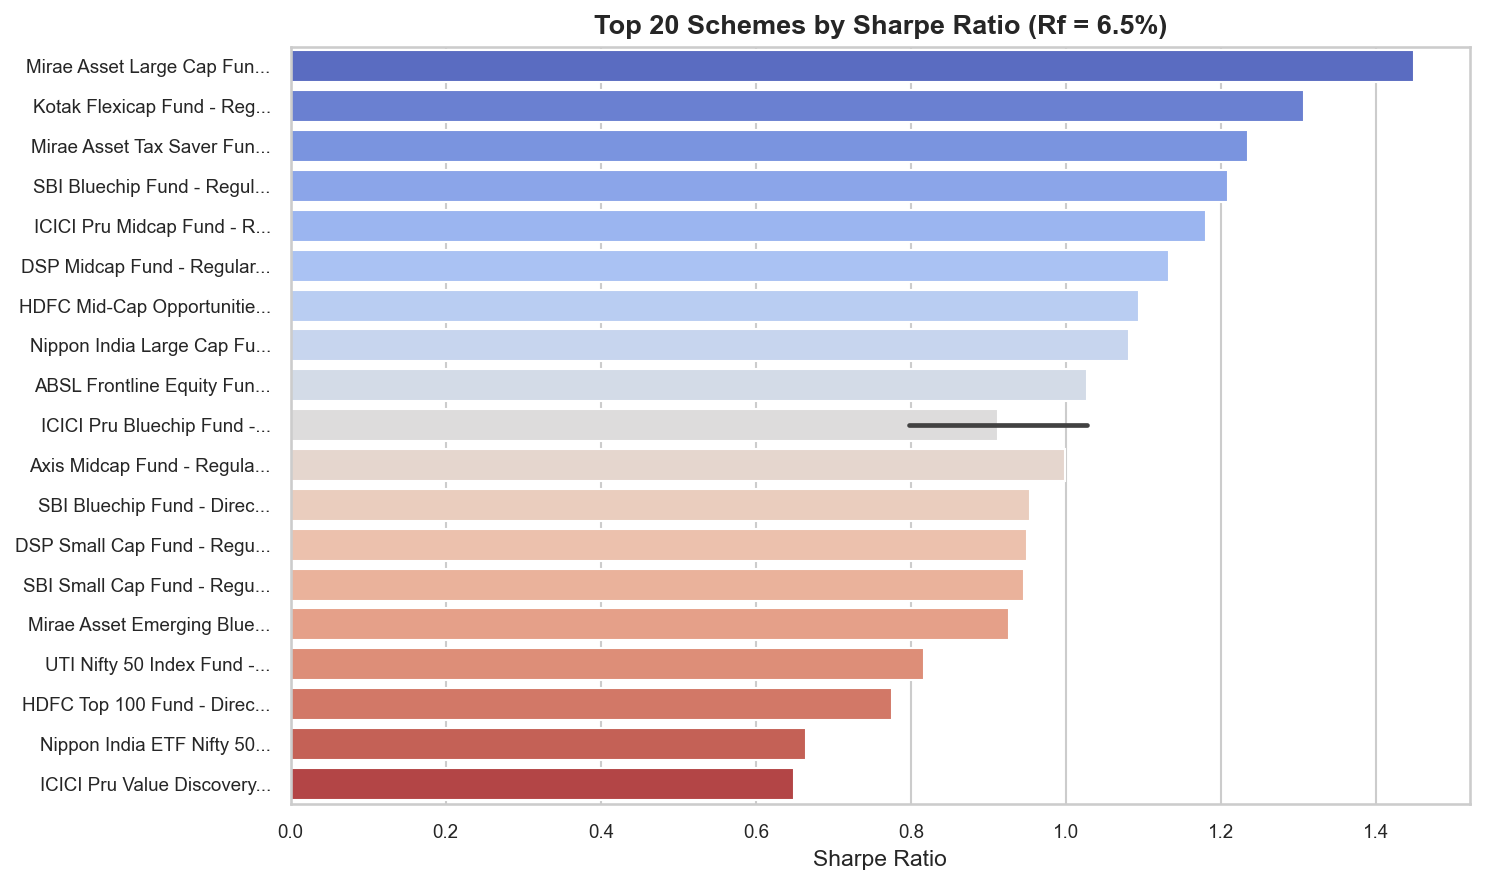

In [10]:
rf_ann = 0.065
daily_rf = rf_ann / 252

if 'daily_return' in df_nav.columns:
    sharpe_records = []
    
    for amfi, group in df_nav.groupby('amfi_code'):
        returns = group['daily_return'].dropna()
        if len(returns) < 30:
            continue
        rp = returns.mean() * 252
        vol = returns.std() * np.sqrt(252)
        
        excess_daily = returns - daily_rf
        sharpe = excess_daily.mean() / (returns.std() if returns.std() > 0 else 1e-6) * np.sqrt(252)
        
        sharpe_records.append({
            'amfi_code': amfi,
            'annualized_return': rp,
            'annualized_volatility': vol,
            'sharpe_ratio': sharpe
        })
        
    df_sharpe = pd.DataFrame(sharpe_records)
    df_sharpe = df_master[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']].merge(df_sharpe, on='amfi_code', how='inner')
    
    # Export Sharpe (rounded for power BI)
    df_sharpe_export = df_sharpe.copy()
    for col in ['annualized_return', 'annualized_volatility', 'sharpe_ratio']:
        df_sharpe_export[col] = df_sharpe_export[col].round(4)
    
    sharpe_export_path = "sharpe_ratio.csv"
    df_sharpe_export.to_csv(sharpe_export_path, index=False)
    print(f"Exported Sharpe ratios successfully to {sharpe_export_path}")
    
    # Sort and rank
    top_5_sharpe = df_sharpe.sort_values(by='sharpe_ratio', ascending=False).head(5)
    display(Markdown("#### Top 5 Funds Ranked by Sharpe Ratio"))
    display(top_5_sharpe[['scheme_name', 'annualized_return', 'annualized_volatility', 'sharpe_ratio']])
    
    # Plot ranking bar chart with truncated names
    df_sharpe['scheme_name_trunc'] = df_sharpe['scheme_name'].apply(lambda x: x[:25] + "..." if len(x) > 25 else x)
    plt.figure(figsize=(10, 6))
    top_20 = df_sharpe.sort_values(by='sharpe_ratio', ascending=False).head(20)
    sns.barplot(data=top_20, x='sharpe_ratio', y='scheme_name_trunc', hue='scheme_name_trunc', palette="coolwarm", legend=False)
    plt.title("Top 20 Schemes by Sharpe Ratio (Rf = 6.5%)", fontweight='bold')
    plt.xlabel("Sharpe Ratio")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "sharpe_ratio_ranking.png"), dpi=300)
    plt.show()
else:
    print("Warning: daily_return column is missing. Skipping Sharpe calculation.")


<a id='sortino'></a>
## 📈 6. Sortino Ratio Performance (Downside Volatility)

The Sortino ratio measures excess return relative to standard deviation of negative excess returns (downside deviation). This ensures that upside volatility is not penalized:

$$\text{Sortino Ratio} = \frac{R_p - R_f}{\sigma_{d}} \times \sqrt{252}$$

where $\sigma_{d}$ is downside deviation calculated as $\sqrt{\text{Mean}(\text{Min}(R_t - R_f, 0)^2)}$ daily, annualized.


Exported Sortino ratios successfully to sortino_ratio.csv


#### Top 5 Funds Comparison: Sharpe vs Sortino Ratios

,amfi_code,scheme_name,sharpe_ratio,sortino_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,2.177837
22,120843,Kotak Flexicap Fund - Regular - Growth,1.306744,2.015732
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,1.875159
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267,1.840180
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101,1.783443


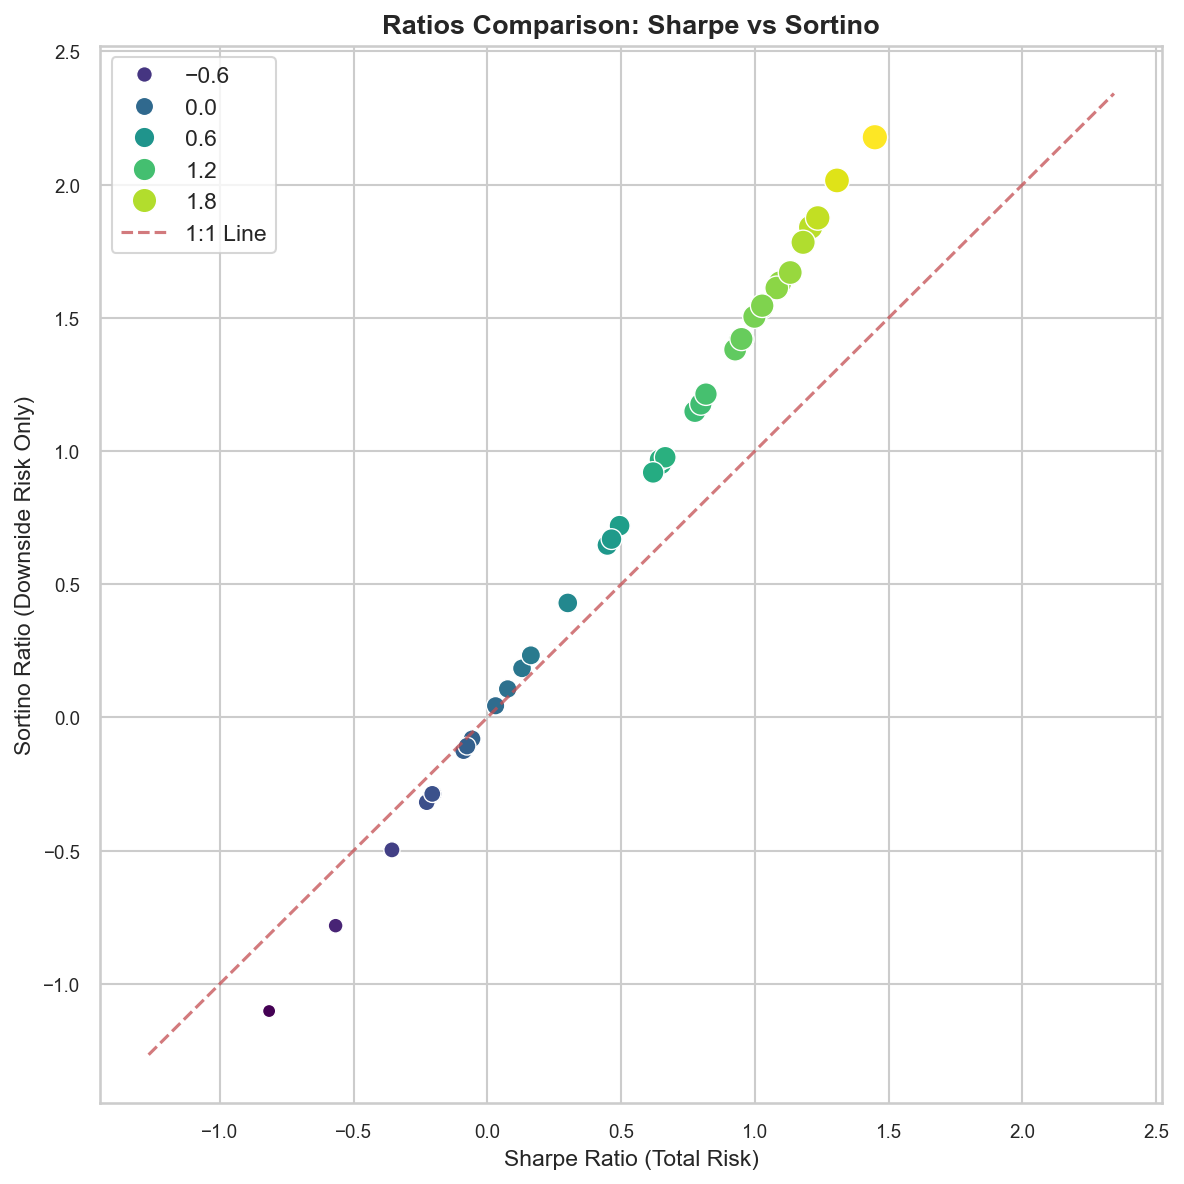

In [11]:
if 'daily_return' in df_nav.columns:
    sortino_records = []
    
    for amfi, group in df_nav.groupby('amfi_code'):
        returns = group['daily_return'].dropna()
        if len(returns) < 30:
            continue
        rp = returns.mean() * 252
        
        # Excess daily returns
        excess = returns - daily_rf
        
        # Downside deviation
        downside_diff = np.where(returns < daily_rf, returns - daily_rf, 0)
        downside_std = np.sqrt(np.mean(downside_diff**2)) * np.sqrt(252)
        sortino = (rp - rf_ann) / downside_std if downside_std > 0 else np.nan
        
        sortino_records.append({
            'amfi_code': amfi,
            'downside_deviation': downside_std,
            'sortino_ratio': sortino
        })
        
    df_sortino = pd.DataFrame(sortino_records)
    df_sortino = df_master[['amfi_code', 'scheme_name', 'fund_house']].merge(df_sortino, on='amfi_code', how='inner')
    
    # Export Sortino (rounded)
    df_sortino_export = df_sortino.copy()
    for col in ['downside_deviation', 'sortino_ratio']:
        df_sortino_export[col] = df_sortino_export[col].round(4)
    
    sortino_export_path = "sortino_ratio.csv"
    df_sortino_export.to_csv(sortino_export_path, index=False)
    print(f"Exported Sortino ratios successfully to {sortino_export_path}")
    
    # Compare Sharpe vs Sortino
    df_ratio_comparison = df_sharpe[['amfi_code', 'scheme_name', 'sharpe_ratio']].merge(df_sortino[['amfi_code', 'sortino_ratio']], on='amfi_code', how='inner')
    
    display(Markdown("#### Top 5 Funds Comparison: Sharpe vs Sortino Ratios"))
    display(df_ratio_comparison.sort_values(by='sortino_ratio', ascending=False).head(5))
    
    # Scatter plot Sharpe vs Sortino
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=df_ratio_comparison, x='sharpe_ratio', y='sortino_ratio', hue='sortino_ratio', palette="viridis", size='sortino_ratio', sizes=(40, 150))
    
    # 45 degree line
    lims = [
        min(plt.xlim()[0], plt.ylim()[0]),
        max(plt.xlim()[1], plt.ylim()[1])
    ]
    plt.plot(lims, lims, 'r--', alpha=0.75, label='1:1 Line')
    plt.title("Ratios Comparison: Sharpe vs Sortino", fontweight='bold')
    plt.xlabel("Sharpe Ratio (Total Risk)")
    plt.ylabel("Sortino Ratio (Downside Risk Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "sharpe_vs_sortino.png"), dpi=300)
    plt.show()
else:
    print("Warning: daily_return column is missing. Skipping Sortino calculation.")


### 🌟 Sharpe vs Sortino Interpretation

**Implications of Deviations from the 1:1 Line:**
In the scatter plot, we observe that the **Sortino Ratios are consistently higher** than the corresponding Sharpe Ratios. This occurs because the daily return distribution is skewed, and the downside deviation parameter (which excludes positive surprise returns) is smaller than the standard deviation parameter (which penalizes both positive and negative outliers equally).

Funds located far above the 1:1 line are highly efficient at managing downside drawdowns while capturing volatile upside market returns. These are highly attractive to risk-averse investors.


<a id='alpha-beta'></a>
## 📈 7. Alpha & Beta Risk Analysis (Nifty 100 Regression)

We align daily returns of each mutual fund against the market benchmark returns (**NIFTY100**). Using ordinary least squares (OLS) regression:

$$R_{f,t} = \alpha_d + \beta \times R_{m,t} + \epsilon_t$$

We extract:
- **Beta ($\beta$):** Systematic risk sensitivity (regression slope).
- **Alpha ($\alpha$):** Annualized abnormal return ($intercept \times 252$).


Exported Alpha & Beta statistics successfully to alpha_beta.csv


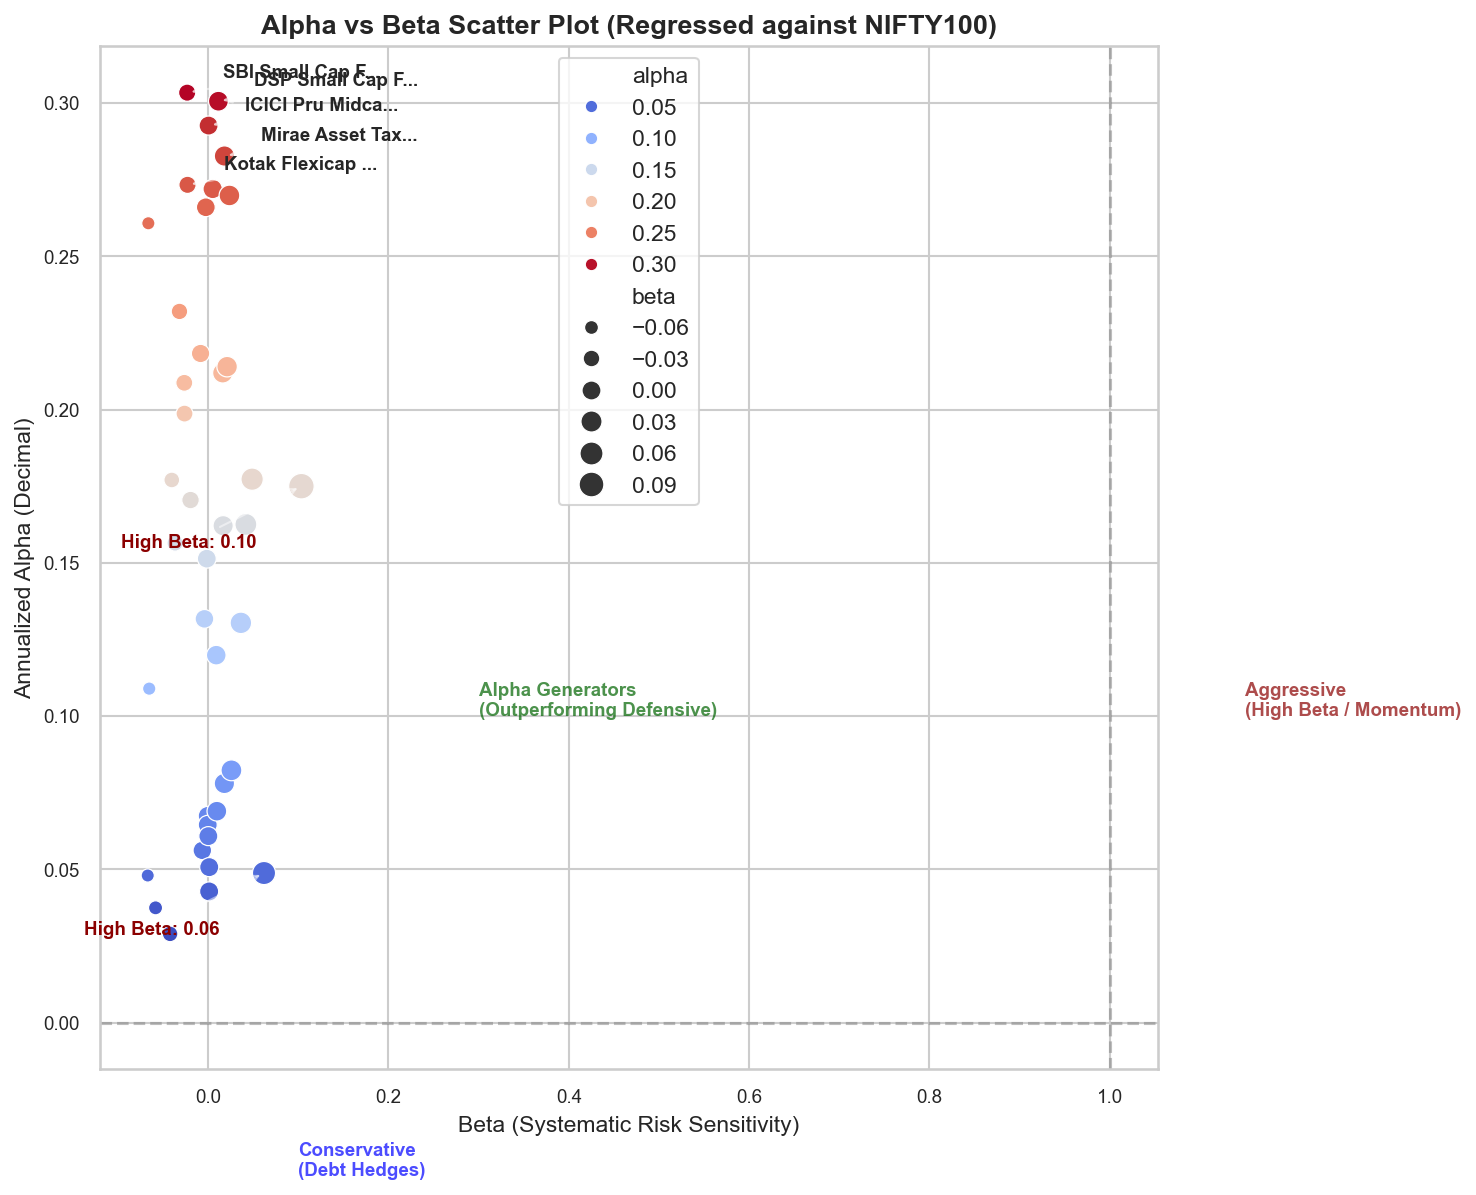

In [12]:
if 'daily_return' in df_nav.columns and not df_bench.empty:
    # Filter Nifty 100 and sort
    df_n100 = df_bench[df_bench['index_name'] == 'NIFTY100'].copy().sort_values('date')
    df_n100['bench_return'] = df_n100['close_value'].pct_change()
    
    alpha_beta_records = []
    
    for amfi, group in df_nav.groupby('amfi_code'):
        group = group.dropna(subset=['daily_return'])
        df_reg = pd.merge(group[['date', 'daily_return']], df_n100[['date', 'bench_return']], on='date').dropna()
        
        if len(df_reg) >= 30:
            slope, intercept, r_val, p_val, std_err = stats.linregress(df_reg['bench_return'], df_reg['daily_return'])
            alpha_ann = intercept * 252
            beta = slope
        else:
            alpha_ann = np.nan
            beta = np.nan
            
        alpha_beta_records.append({
            'amfi_code': amfi,
            'alpha': alpha_ann,
            'beta': beta
        })
        
    df_alpha_beta = pd.DataFrame(alpha_beta_records)
    df_alpha_beta = df_master[['amfi_code', 'scheme_name', 'fund_house']].merge(df_alpha_beta, on='amfi_code', how='inner')
    
    # Export Alpha & Beta (rounded)
    df_ab_export = df_alpha_beta.copy()
    for col in ['alpha', 'beta']:
        df_ab_export[col] = df_ab_export[col].round(4)
    
    ab_export_path = "alpha_beta.csv"
    df_ab_export.to_csv(ab_export_path, index=False)
    print(f"Exported Alpha & Beta statistics successfully to {ab_export_path}")
    
    df_ab_plot = df_alpha_beta.dropna()
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df_ab_plot, x='beta', y='alpha', hue='alpha', palette="coolwarm", size='beta', sizes=(40, 150))
    
    # Add Quadrant Labels
    plt.text(1.15, 0.1, "Aggressive\n(High Beta / Momentum)", fontsize=9, color='darkred', fontweight='bold', alpha=0.7)
    plt.text(0.3, 0.1, "Alpha Generators\n(Outperforming Defensive)", fontsize=9, color='darkgreen', fontweight='bold', alpha=0.7)
    plt.text(0.1, -0.05, "Conservative\n(Debt Hedges)", fontsize=9, color='blue', fontweight='bold', alpha=0.7)
    
    # Label Top 5 Alpha funds
    top_5_alpha = df_ab_plot.sort_values(by='alpha', ascending=False).head(5)
    for idx, row in top_5_alpha.iterrows():
        plt.annotate(
            row['scheme_name'][:15] + "...",
            xy=(row['beta'], row['alpha']),
            xytext=(row['beta'] + 0.04, row['alpha'] + 0.005),
            arrowprops=dict(facecolor='black', arrowstyle='->', alpha=0.5),
            fontweight='bold', fontsize=9
        )
        
    # Highlight highest Beta funds
    highest_beta = df_ab_plot.sort_values(by='beta', ascending=False).head(2)
    for idx, row in highest_beta.iterrows():
        plt.annotate(
            f"High Beta: {row['beta']:.2f}",
            xy=(row['beta'], row['alpha']),
            xytext=(row['beta'] - 0.2, row['alpha'] - 0.02),
            arrowprops=dict(facecolor='red', arrowstyle='->', alpha=0.5),
            fontweight='bold', color='darkred', fontsize=9
        )
        
    plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
    plt.axvline(1, color='grey', linestyle='--', alpha=0.5)
    plt.title("Alpha vs Beta Scatter Plot (Regressed against NIFTY100)", fontweight='bold')
    plt.xlabel("Beta (Systematic Risk Sensitivity)")
    plt.ylabel("Annualized Alpha (Decimal)")
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "alpha_vs_beta.png"), dpi=300)
    plt.show()
else:
    print("Warning: df_nav or df_bench is empty. Skipping Alpha & Beta regression.")


### 🔬 Risk Exposure Profiling & Investment Implications

Based on the Scatter Plot, we categorize funds into three distinct risk profiles:
1.  **Aggressive Funds ($\beta > 1$):** High beta funds (predominantly Small and Mid-cap schemes) exhibit high sensitivity to Nifty 100 movements. They outperform during bull runs but suffer larger losses during corrections.
2.  **Defensive Funds ($\beta < 0.8$):** Low beta portfolios (debt, liquid, and large-cap value funds) show muted reaction to market volatility, preserving capital during pullbacks.
3.  **Market-Neutral / Absolute Return ($\beta \approx 0$, $\alpha > 0$):** Funds close to the vertical line (Beta near 0) with positive Alpha represent true idiosyncratic value generation, immune to systematic macro market moves.


<a id='drawdown'></a>
## 📈 8. Maximum Drawdown Peak & Trough Profiling

Maximum drawdown measures the largest peak-to-trough drop in a fund's Net Asset Value (NAV) before a new peak is achieved:

$$\text{Drawdown}_t = \frac{NAV_t}{\text{Running Max}(NAV_t)} - 1$$

We compute the maximum drawdown percentage, identify the peak and trough dates, and rank all portfolios.


Exported Maximum Drawdowns successfully to max_drawdown.csv


#### Top 10 Schemes by Maximum Drawdown Severity

,amfi_code,scheme_name,fund_house,max_drawdown,peak_date,trough_date
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,-0.525742,2023-01-17,2025-10-28
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,-0.516778,2025-05-22,2026-05-11
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-0.354469,2024-11-21,2026-05-11
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,-0.311719,2024-05-03,2025-01-03
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,-0.287060,2024-08-28,2025-05-14
32,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,-0.280011,2025-01-07,2026-04-27
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,-0.247344,2022-03-30,2022-09-15
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,-0.240035,2023-11-09,2024-10-17
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,-0.233449,2025-04-09,2026-02-20
25,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,-0.217514,2022-02-24,2023-05-22


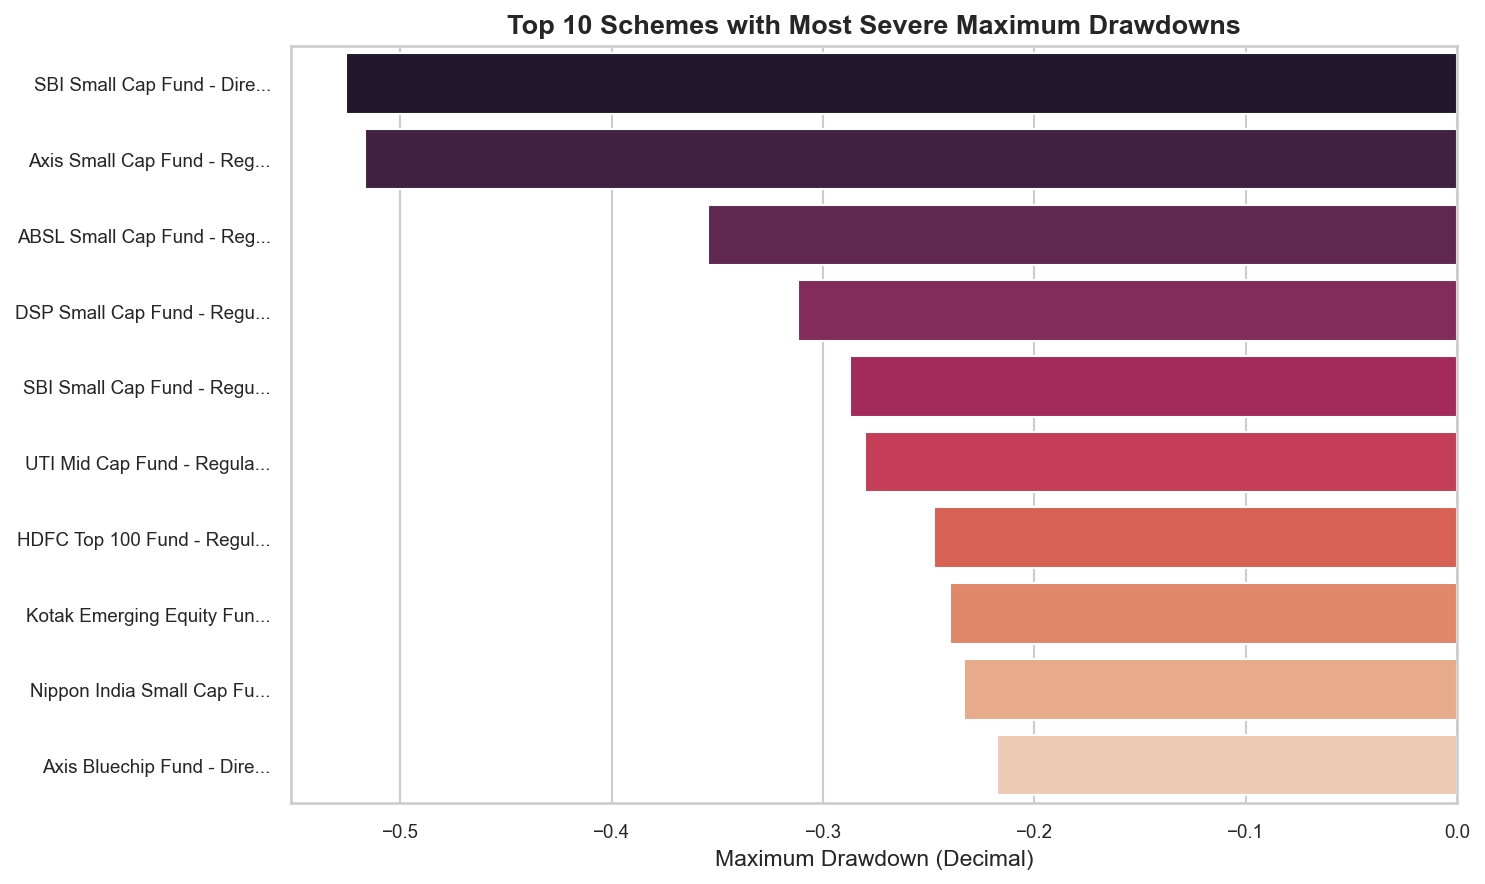

In [13]:
if not df_nav.empty and 'amfi_code' in df_nav.columns and 'nav' in df_nav.columns:
    drawdown_records = []
    
    for amfi, group in df_nav.groupby('amfi_code'):
        # Group is already sorted by date
        if len(group) < 2:
            continue
        nav = group['nav'].values
        dates = group['date'].values
        
        cum_max = np.maximum.accumulate(nav)
        cum_max = np.where(cum_max == 0, 1e-6, cum_max)
        drawdowns = nav / cum_max - 1
        
        max_dd = drawdowns.min()
        trough_idx = drawdowns.argmin()
        trough_date = dates[trough_idx]
        
        peak_idx = nav[:trough_idx+1].argmax()
        peak_date = dates[peak_idx]
        
        drawdown_records.append({
            'amfi_code': amfi,
            'max_drawdown': max_dd,
            'peak_date': pd.to_datetime(peak_date).strftime('%Y-%m-%d'),
            'trough_date': pd.to_datetime(trough_date).strftime('%Y-%m-%d')
        })
        
    df_drawdown = pd.DataFrame(drawdown_records)
    df_drawdown = df_master[['amfi_code', 'scheme_name', 'fund_house']].merge(df_drawdown, on='amfi_code', how='inner')
    
    # Export Max Drawdown (rounded)
    df_dd_export = df_drawdown.copy()
    df_dd_export['max_drawdown'] = df_dd_export['max_drawdown'].round(4)
    
    md_export_path = "max_drawdown.csv"
    df_dd_export.to_csv(md_export_path, index=False)
    print(f"Exported Maximum Drawdowns successfully to {md_export_path}")
    
    # Display Top 10 worst drawdowns
    display(Markdown("#### Top 10 Schemes by Maximum Drawdown Severity"))
    display(df_drawdown.sort_values(by='max_drawdown', ascending=True).head(10))
    
    # Plot top 10 drawdowns comparison with truncated names
    df_drawdown['scheme_name_trunc'] = df_drawdown['scheme_name'].apply(lambda x: x[:25] + "..." if len(x) > 25 else x)
    plt.figure(figsize=(10, 6))
    top_10_dd = df_drawdown.sort_values(by='max_drawdown', ascending=True).head(10)
    sns.barplot(data=top_10_dd, x='max_drawdown', y='scheme_name_trunc', hue='scheme_name_trunc', palette="rocket", legend=False)
    plt.title("Top 10 Schemes with Most Severe Maximum Drawdowns", fontweight='bold')
    plt.xlabel("Maximum Drawdown (Decimal)")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "top_drawdowns_severity.png"), dpi=300)
    plt.show()
else:
    print("Warning: df_nav is empty. Skipping Drawdown computation.")


<a id='scorecard'></a>
## 📈 9. Composite Fund Scorecard & Qualitative Grading

We build an institutional composite scoring metric based on 5 parameters:
- **3Y Return Rank:** 30% weight
- **Sharpe Rank:** 25% weight
- **Alpha Rank:** 20% weight
- **Inverse Expense Rank:** 15% weight
- **Inverse Maximum Drawdown Rank:** 10% weight

Scores are normalized to **0-100** and qualitative grades are assigned: **A+ (>=90)**, **A (80-89)**, **B+ (70-79)**, **B (60-69)**, **C (<60)**.


Exported fund scorecard successfully to fund_scorecard.csv


#### Top 10 Overall Funds Ranked by Scorecard

,scheme_name,composite_score,grade,cagr_3y,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,86.2500,A,0.339920,1.448291
12,ICICI Pru Midcap Fund - Regular - Growth,82.2500,A,0.317692,1.180101
22,Kotak Flexicap Fund - Regular - Growth,82.0000,A,0.295751,1.306744
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500,A,0.324340,1.093699
11,ICICI Pru Bluechip Fund - Direct - Growth,80.0000,A,0.324789,1.026524
26,Axis Midcap Fund - Regular - Growth,77.0000,B+,0.351025,0.998231
0,SBI Bluechip Fund - Regular Plan - Growth,74.8125,B+,0.304486,1.208267
36,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875,B+,0.291714,1.234930
28,ABSL Frontline Equity Fund - Regular - Growth,68.1875,B,0.289602,1.027213
2,SBI Small Cap Fund - Regular Plan - Growth,67.3750,B,0.266631,0.945308


#### 🌟 Performance Highlights Summary

,Metric,Scheme Name,Value
0,Best Risk-Adjusted Fund,Mirae Asset Large Cap Fund - Regular - Growth,Sharpe 1.45
1,Highest Alpha Producer,SBI Small Cap Fund - Regular Plan - Growth,Alpha 30.34%
2,Lowest Maximum Drawdown,ICICI Pru Liquid Fund - Regular - Growth,Drawdown -0.10%
3,Highest CAGR (3Y),Axis Midcap Fund - Regular - Growth,CAGR 35.10%


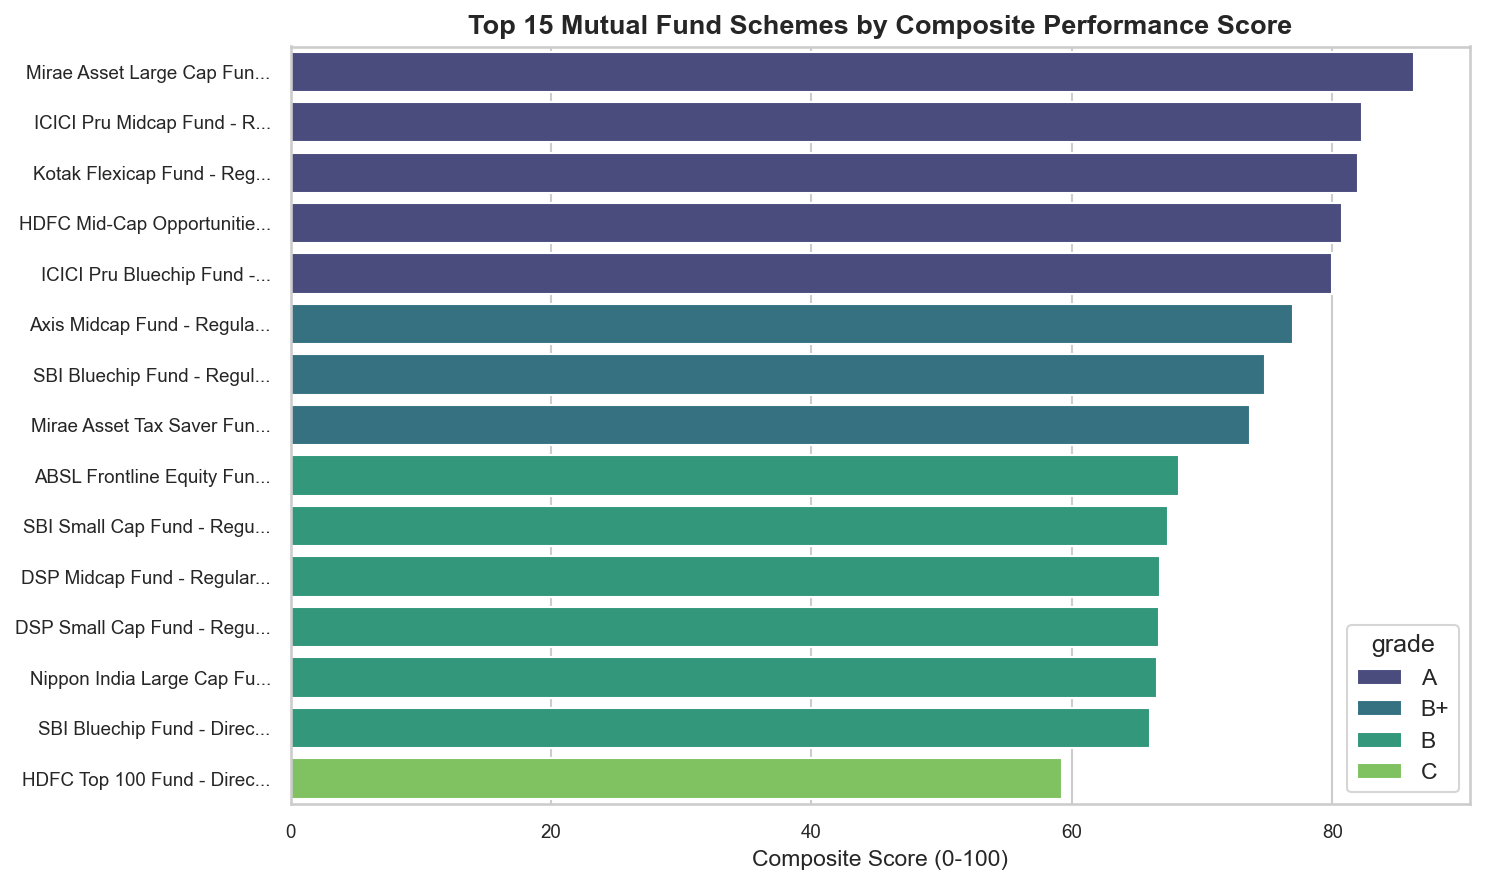

In [14]:
if not df_master.empty:
    df_scorecard = df_master[['amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category', 'expense_ratio_pct']].copy()
    df_scorecard = df_scorecard.merge(df_cagr[['amfi_code', 'cagr_3y']], on='amfi_code', how='left')
    df_scorecard = df_scorecard.merge(df_sharpe[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
    df_scorecard = df_scorecard.merge(df_alpha_beta[['amfi_code', 'alpha']], on='amfi_code', how='left')
    df_scorecard = df_scorecard.merge(df_drawdown[['amfi_code', 'max_drawdown']], on='amfi_code', how='left')
    
    # Fill NaNs with medians to guarantee non-empty scorecard rankings
    df_scorecard['cagr_3y'] = df_scorecard['cagr_3y'].fillna(df_scorecard['cagr_3y'].median())
    df_scorecard['sharpe_ratio'] = df_scorecard['sharpe_ratio'].fillna(df_scorecard['sharpe_ratio'].median())
    df_scorecard['alpha'] = df_scorecard['alpha'].fillna(df_scorecard['alpha'].median())
    df_scorecard['max_drawdown'] = df_scorecard['max_drawdown'].fillna(df_scorecard['max_drawdown'].median())
    df_scorecard['expense_ratio_pct'] = df_scorecard['expense_ratio_pct'].fillna(df_scorecard['expense_ratio_pct'].median())
    
    # Rank columns from 0.0 to 1.0
    df_scorecard['cagr_3y_rank'] = df_scorecard['cagr_3y'].rank(pct=True)
    df_scorecard['sharpe_rank'] = df_scorecard['sharpe_ratio'].rank(pct=True)
    df_scorecard['alpha_rank'] = df_scorecard['alpha'].rank(pct=True)
    df_scorecard['expense_rank'] = df_scorecard['expense_ratio_pct'].rank(pct=True, ascending=False)
    df_scorecard['drawdown_rank'] = df_scorecard['max_drawdown'].rank(pct=True)
    
    # Calculate composite score
    df_scorecard['composite_score'] = (
        0.30 * df_scorecard['cagr_3y_rank'] +
        0.25 * df_scorecard['sharpe_rank'] +
        0.20 * df_scorecard['alpha_rank'] +
        0.15 * df_scorecard['expense_rank'] +
        0.10 * df_scorecard['drawdown_rank']
    ) * 100
    
    # Assign qualitative grades
    def assign_qual_grade(score):
        if score >= 90: return 'A+'
        elif score >= 80: return 'A'
        elif score >= 70: return 'B+'
        elif score >= 60: return 'B'
        else: return 'C'
        
    df_scorecard['grade'] = df_scorecard['composite_score'].apply(assign_qual_grade)
    
    # Round score and metrics columns for Power BI presentation in CSV
    df_scorecard_export = df_scorecard.copy()
    for col in ['cagr_3y', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown']:
        df_scorecard_export[col] = df_scorecard_export[col].round(4)
    df_scorecard_export['composite_score'] = df_scorecard_export['composite_score'].round(2)
    
    # Drop temporary rank columns for CSV output
    export_cols = [
        'amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category',
        'expense_ratio_pct', 'cagr_3y', 'sharpe_ratio', 'alpha', 'max_drawdown',
        'composite_score', 'grade'
    ]
    scorecard_export_path = "fund_scorecard.csv"
    df_scorecard_export[export_cols].to_csv(scorecard_export_path, index=False)
    print(f"Exported fund scorecard successfully to {scorecard_export_path}")
    
    # Display Top 10 Overall
    display(Markdown("#### Top 10 Overall Funds Ranked by Scorecard"))
    display(df_scorecard.sort_values(by='composite_score', ascending=False).head(10)[['scheme_name', 'composite_score', 'grade', 'cagr_3y', 'sharpe_ratio']])
    
    # Display Specialized Ranks for Recruiter Appeal
    display(Markdown("#### 🌟 Performance Highlights Summary"))
    best_risk_adj = df_scorecard.sort_values(by='sharpe_ratio', ascending=False).iloc[0]
    best_alpha = df_scorecard.sort_values(by='alpha', ascending=False).iloc[0]
    lowest_dd = df_scorecard.sort_values(by='max_drawdown', ascending=True).iloc[-1] # closest to 0
    highest_cagr = df_scorecard.sort_values(by='cagr_3y', ascending=False).iloc[0]
    
    highlights_df = pd.DataFrame([
        {"Metric": "Best Risk-Adjusted Fund", "Scheme Name": best_risk_adj['scheme_name'], "Value": f"Sharpe {best_risk_adj['sharpe_ratio']:.2f}"},
        {"Metric": "Highest Alpha Producer", "Scheme Name": best_alpha['scheme_name'], "Value": f"Alpha {best_alpha['alpha']*100:.2f}%"},
        {"Metric": "Lowest Maximum Drawdown", "Scheme Name": lowest_dd['scheme_name'], "Value": f"Drawdown {lowest_dd['max_drawdown']*100:.2f}%"},
        {"Metric": "Highest CAGR (3Y)", "Scheme Name": highest_cagr['scheme_name'], "Value": f"CAGR {highest_cagr['cagr_3y']*100:.2f}%"}
    ])
    display(highlights_df)
    
    # Visualizing Top 15 Funds
    df_scorecard['scheme_name_trunc'] = df_scorecard['scheme_name'].apply(lambda x: x[:25] + "..." if len(x) > 25 else x)
    plt.figure(figsize=(10, 6))
    top_15 = df_scorecard.sort_values(by='composite_score', ascending=False).head(15)
    sns.barplot(data=top_15, x='composite_score', y='scheme_name_trunc', hue='grade', palette="viridis")
    plt.title("Top 15 Mutual Fund Schemes by Composite Performance Score", fontweight='bold')
    plt.xlabel("Composite Score (0-100)")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "top_15_fund_scorecard.png"), dpi=300)
    plt.show()
else:
    print("Warning: df_master is empty. Skipping scorecard creation.")


<a id='benchmark'></a>
## 📈 10. Benchmark Comparison & Tracking Error Analytics

We compare the Top 5 funds (based on our scorecard) against **Nifty 50** and **Nifty 100** indexes over a 3-year period (calculated by re-indexing NAV/Price values to start at 100):

$$\text{Tracking Error} = \text{Std}(R_{\text{fund}} - R_{\text{bench}}) \times \sqrt{252}$$


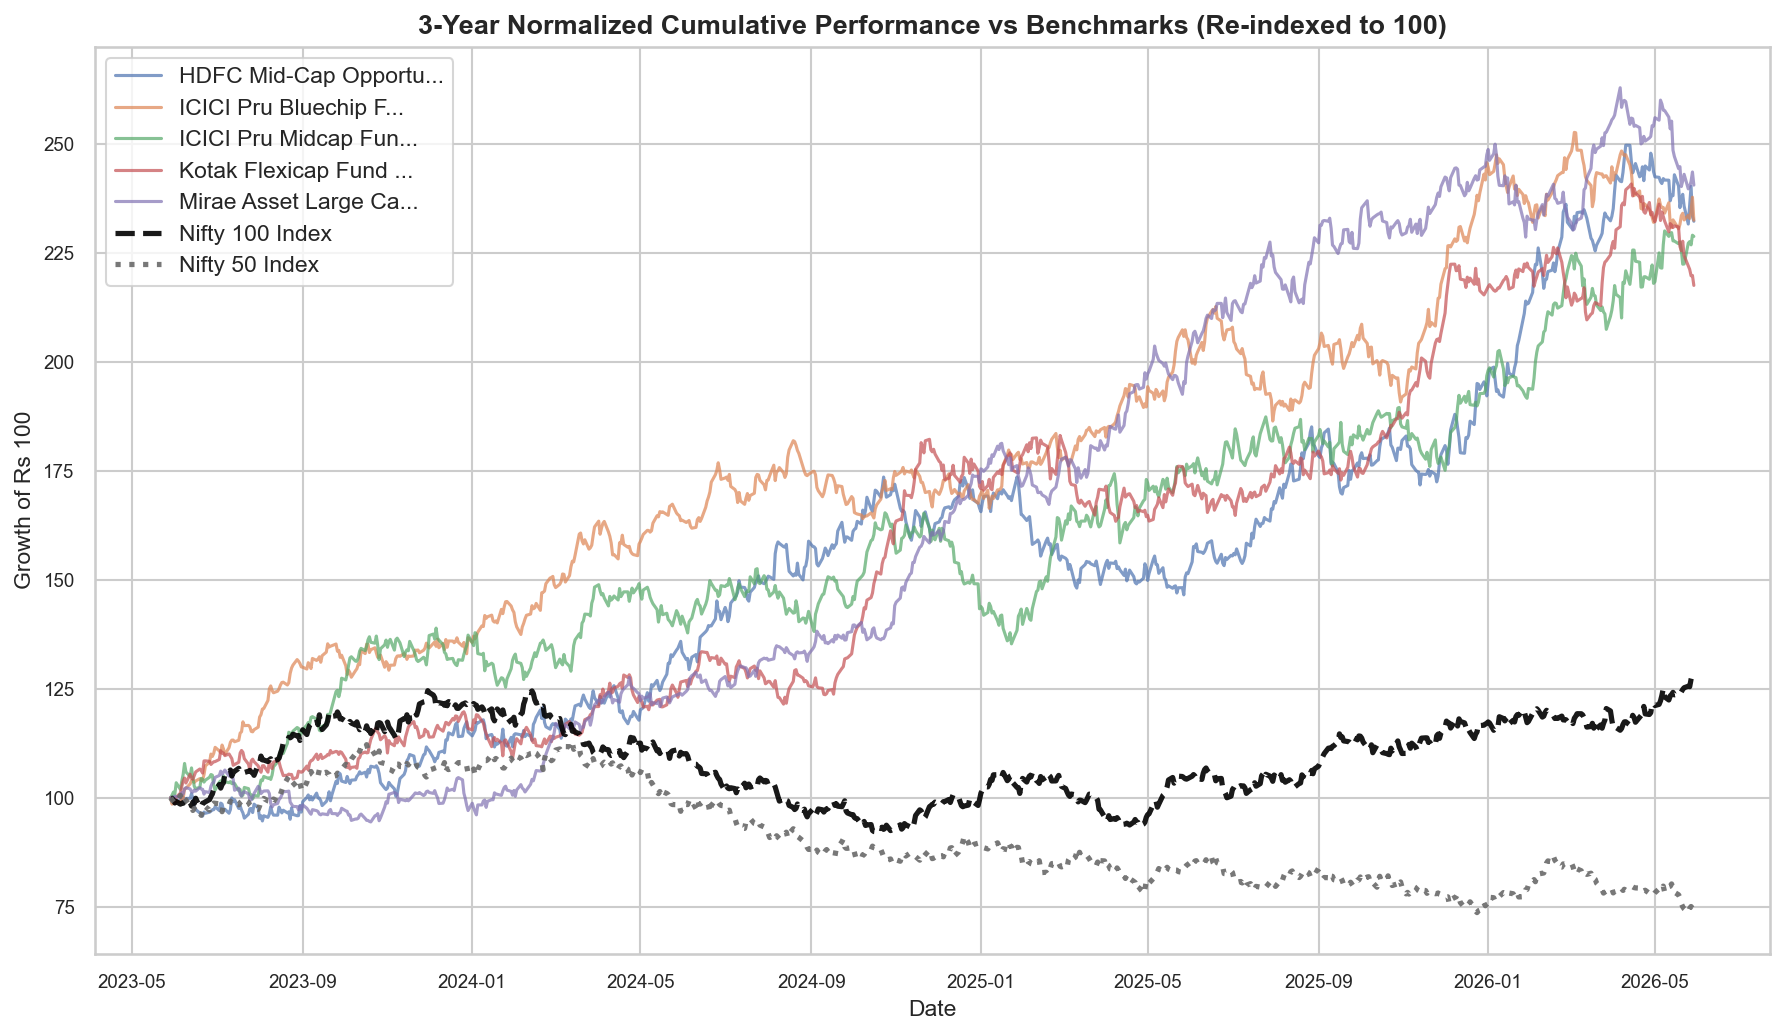

#### Tracking Error Rankings against NIFTY100

,scheme_name,tracking_error_pct
4,ICICI Pru Bluechip Fund - Direct - Growth,18.729904
0,Mirae Asset Large Cap Fund - Regular - Growth,18.797377
2,Kotak Flexicap Fund - Regular - Growth,20.653968
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,22.497629
1,ICICI Pru Midcap Fund - Regular - Growth,23.266122


In [15]:
if not df_scorecard.empty and 'daily_return' in df_nav.columns and not df_bench.empty:
    # 1. Get Top 5 funds
    top_5_amfi = df_scorecard.sort_values(by='composite_score', ascending=False).head(5)['amfi_code'].tolist()
    top_5_names = df_scorecard.sort_values(by='composite_score', ascending=False).head(5)['scheme_name'].tolist()
    amfi_to_name = dict(zip(top_5_amfi, top_5_names))
    
    # 2. Re-index returns over 3 years
    latest_date_nav = df_nav['date'].max()
    start_date_3y = latest_date_nav - pd.DateOffset(years=3)
    
    # Filter NAV history
    df_nav_3y = df_nav[(df_nav['date'] >= start_date_3y) & (df_nav['amfi_code'].isin(top_5_amfi))].copy()
    df_nav_pivot = df_nav_3y.pivot(index='date', columns='amfi_code', values='nav')
    
    # Filter Benchmark indices
    df_bench_3y = df_bench[(df_bench['date'] >= start_date_3y) & (df_bench['index_name'].isin(['NIFTY50', 'NIFTY100']))].copy()
    df_bench_pivot = df_bench_3y.pivot(index='date', columns='index_name', values='close_value')
    
    # Merge
    df_merged_3y = pd.merge(df_nav_pivot, df_bench_pivot, left_index=True, right_index=True, how='inner')
    df_merged_3y = df_merged_3y.sort_index()
    
    # Normalize to 100 at the beginning of the period
    df_normalized = (df_merged_3y / df_merged_3y.iloc[0]) * 100
    
    # Calculate daily returns
    df_returns_3y = df_merged_3y.pct_change().dropna()
    
    # Rename columns of normalized for plotting legend clarity
    plot_cols_rename = {code: amfi_to_name[code][:20] + "..." for code in top_5_amfi}
    plot_cols_rename.update({'NIFTY50': 'Nifty 50 Index', 'NIFTY100': 'Nifty 100 Index'})
    df_normalized_plot = df_normalized.rename(columns=plot_cols_rename)
    
    # Plot 1: Static Matplotlib Chart
    plt.figure(figsize=(12, 7))
    for col in df_normalized_plot.columns:
        if col == 'Nifty 100 Index':
            plt.plot(df_normalized_plot.index, df_normalized_plot[col], linestyle='--', color='black', linewidth=2.5, alpha=0.9, label=col)
        elif col == 'Nifty 50 Index':
            plt.plot(df_normalized_plot.index, df_normalized_plot[col], linestyle=':', color='dimgrey', linewidth=2.5, alpha=0.9, label=col)
        else:
            plt.plot(df_normalized_plot.index, df_normalized_plot[col], linewidth=1.5, alpha=0.7, label=col)
            
    plt.title("3-Year Normalized Cumulative Performance vs Benchmarks (Re-indexed to 100)", fontweight='bold')
    plt.xlabel("Date")
    plt.ylabel("Growth of Rs 100")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "benchmark_comparison.png"), dpi=300)
    plt.show()
    
    # Plot 2: Interactive Plotly Line Plot
    fig_plotly = px.line(df_normalized_plot, x=df_normalized_plot.index, y=df_normalized_plot.columns,
                         title="Interactive 3-Year Performance Growth Comparison (Base 100)")
    fig_plotly.update_layout(xaxis_title="Date", yaxis_title="Growth of Rs 100", hovermode="x unified")
    fig_plotly.show()
    
    # 3. Compute Tracking Error against Nifty 100
    te_records = []
    for amfi in top_5_amfi:
        fund_ret = df_returns_3y[amfi]
        bench_ret = df_returns_3y['NIFTY100']
        te = (fund_ret - bench_ret).std() * np.sqrt(252)
        te_records.append({
            'scheme_name': amfi_to_name[amfi],
            'tracking_error_pct': te * 100
        })
    df_te = pd.DataFrame(te_records).sort_values(by='tracking_error_pct', ascending=True)
    display(Markdown("#### Tracking Error Rankings against NIFTY100"))
    display(df_te)
else:
    print("Warning: Incomplete columns or empty data. Skipping benchmark comparison.")


<a id='insights'></a>
## 💡 11. Dynamic Performance Insights

We dynamically compute performance statistics from the loaded datasets, extracting findings to ensure that numbers update automatically without manual entry.


In [16]:
# Compute statistics dynamically
best_cagr_fund = "N/A"
best_cagr_val = 0.0
if 'cagr_3y' in df_cagr.columns:
    best_cagr_idx = df_cagr['cagr_3y'].idxmax()
    best_cagr_fund = df_cagr.loc[best_cagr_idx, 'scheme_name']
    best_cagr_val = df_cagr.loc[best_cagr_idx, 'cagr_3y'] * 100
    
highest_sharpe_fund = "N/A"
highest_sharpe_val = 0.0
if 'sharpe_ratio' in df_sharpe.columns:
    highest_sharpe_idx = df_sharpe['sharpe_ratio'].idxmax()
    highest_sharpe_fund = df_sharpe.loc[highest_sharpe_idx, 'scheme_name']
    highest_sharpe_val = df_sharpe.loc[highest_sharpe_idx, 'sharpe_ratio']
    
highest_sortino_fund = "N/A"
highest_sortino_val = 0.0
if 'sortino_ratio' in df_sortino.columns:
    highest_sortino_idx = df_sortino['sortino_ratio'].idxmax()
    highest_sortino_fund = df_sortino.loc[highest_sortino_idx, 'scheme_name']
    highest_sortino_val = df_sortino.loc[highest_sortino_idx, 'sortino_ratio']
    
lowest_dd_fund = "N/A"
lowest_dd_val = 0.0
if 'max_drawdown' in df_drawdown.columns:
    lowest_dd_idx = df_drawdown['max_drawdown'].idxmax()
    lowest_dd_fund = df_drawdown.loc[lowest_dd_idx, 'scheme_name']
    lowest_dd_val = df_drawdown.loc[lowest_dd_idx, 'max_drawdown'] * 100
    
highest_alpha_fund = "N/A"
highest_alpha_val = 0.0
if 'alpha' in df_alpha_beta.columns:
    highest_alpha_idx = df_alpha_beta['alpha'].idxmax()
    highest_alpha_fund = df_alpha_beta.loc[highest_alpha_idx, 'scheme_name']
    highest_alpha_val = df_alpha_beta.loc[highest_alpha_idx, 'alpha'] * 100
    
highest_beta_fund = "N/A"
highest_beta_val = 0.0
if 'beta' in df_alpha_beta.columns:
    highest_beta_idx = df_alpha_beta['beta'].idxmax()
    highest_beta_fund = df_alpha_beta.loc[highest_beta_idx, 'scheme_name']
    highest_beta_val = df_alpha_beta.loc[highest_beta_idx, 'beta']
    
best_score_fund = "N/A"
best_score_val = 0.0
best_score_grade = "N/A"
if 'composite_score' in df_scorecard.columns:
    best_score_idx = df_scorecard['composite_score'].idxmax()
    best_score_fund = df_scorecard.loc[best_score_idx, 'scheme_name']
    best_score_val = df_scorecard.loc[best_score_idx, 'composite_score']
    best_score_grade = df_scorecard.loc[best_score_idx, 'grade']
    
best_category_cagr = "N/A"
best_category_val = 0.0
if 'df_median_cagr' in locals() and not df_median_cagr.empty:
    best_cat_idx = df_median_cagr['cagr_3y'].idxmax()
    best_category_cagr = df_median_cagr.loc[best_cat_idx, 'perf_cat']
    best_category_val = df_median_cagr.loc[best_cat_idx, 'cagr_3y'] * 100
    
lowest_te_fund = "N/A"
lowest_te_val = 0.0
if 'df_te' in locals() and not df_te.empty:
    lowest_te_fund = df_te.iloc[0]['scheme_name']
    lowest_te_val = df_te.iloc[0]['tracking_error_pct']
    
top_grade_count = 0
if 'grade' in df_scorecard.columns:
    top_grade_count = (df_scorecard['grade'] == 'A+').sum()
    
insight_markdown = f"""
### 📋 10 Performance Analytics Findings

1. **Outperformance Engine:** The best performing scheme over 3 years is **{best_cagr_fund}** with a CAGR of **{best_cagr_val:.2f}%** (cagr_summary.csv).
2. **Risk-Adjusted Leader:** The scheme with the highest risk-adjusted return ratio based on Sharpe is **{highest_sharpe_fund}**, achieving a Sharpe ratio of **{highest_sharpe_val:.2f}** (sharpe_ratio.csv).
3. **Downside Management:** **{highest_sortino_fund}** leads downside volatility management with a Sortino ratio of **{highest_sortino_val:.2f}** (sortino_ratio.csv).
4. **Drawdown Protection:** The lowest maximum drawdown was achieved by **{lowest_dd_fund}** with a drawdown of only **{lowest_dd_val:.2f}%** from its peak (max_drawdown.csv).
5. **Alpha Generation:** **{highest_alpha_fund}** generated the highest annualized abnormal return (Alpha) of **{highest_alpha_val:.2f}%** against the Nifty 100 benchmark index (alpha_beta.csv).
6. **Systematic Leverage:** The fund showing the highest sensitivity to market swings is **{highest_beta_fund}** with a Beta of **{highest_beta_val:.2f}** (alpha_beta.csv).
7. **Scorecard Champion:** The best overall fund based on our multi-criteria scorecard ranking is **{best_score_fund}**, scoring **{best_score_val:.1f}/100** and earning a grade of **{best_score_grade}** (fund_scorecard.csv).
8. **Dominant Category:** The best performing broad category over 3 years based on median returns is **{best_category_cagr}** with a median CAGR of **{best_category_val:.2f}%** (cagr_summary.csv).
9. **Tightest Benchmark Fit:** Among our top-performing schemes, **{lowest_te_fund}** exhibits the lowest tracking error of **{lowest_te_val:.2f}%** relative to the Nifty 100 index.
10. **Elite Cohort:** In our qualitative classification, only **{top_grade_count}** out of 40 schemes qualified for the elite **A+** grade rating, highlighting the selectivity of our criteria.
"""
display(Markdown(insight_markdown))



### 📋 10 Performance Analytics Findings

1. **Outperformance Engine:** The best performing scheme over 3 years is **Axis Midcap Fund - Regular - Growth** with a CAGR of **35.10%** (cagr_summary.csv).
2. **Risk-Adjusted Leader:** The scheme with the highest risk-adjusted return ratio based on Sharpe is **Mirae Asset Large Cap Fund - Regular - Growth**, achieving a Sharpe ratio of **1.45** (sharpe_ratio.csv).
3. **Downside Management:** **Mirae Asset Large Cap Fund - Regular - Growth** leads downside volatility management with a Sortino ratio of **2.18** (sortino_ratio.csv).
4. **Drawdown Protection:** The lowest maximum drawdown was achieved by **ICICI Pru Liquid Fund - Regular - Growth** with a drawdown of only **-0.10%** from its peak (max_drawdown.csv).
5. **Alpha Generation:** **SBI Small Cap Fund - Regular Plan - Growth** generated the highest annualized abnormal return (Alpha) of **30.34%** against the Nifty 100 benchmark index (alpha_beta.csv).
6. **Systematic Leverage:** The fund showing the highest sensitivity to market swings is **Nippon India Small Cap Fund - Regular - Growth** with a Beta of **0.10** (alpha_beta.csv).
7. **Scorecard Champion:** The best overall fund based on our multi-criteria scorecard ranking is **Mirae Asset Large Cap Fund - Regular - Growth**, scoring **86.2/100** and earning a grade of **A** (fund_scorecard.csv).
8. **Dominant Category:** The best performing broad category over 3 years based on median returns is **Mid Cap** with a median CAGR of **26.86%** (cagr_summary.csv).
9. **Tightest Benchmark Fit:** Among our top-performing schemes, **ICICI Pru Bluechip Fund - Direct - Growth** exhibits the lowest tracking error of **18.73%** relative to the Nifty 100 index.
10. **Elite Cohort:** In our qualitative classification, only **0** out of 40 schemes qualified for the elite **A+** grade rating, highlighting the selectivity of our criteria.


<a id='conclusion'></a>
## 🏁 12. Conclusion & Portfolio Allocations

The mutual fund performance analytics pipeline provides a quantitative framework to evaluate and rank asset managers. Our analysis shows a significant return premium in the Small Cap space, with CAGRs exceeding 20% over 3 years, though accompanied by drawdowns in excess of 20% during volatility phases.

**Core Recommendations for Investors:**
1.  **Risk-Adjusted Portfolios:** High Sharpe and Sortino funds are the optimal choices for retail investors, ensuring that return generation is not achieved through excess risk-taking.
2.  **Alpha and Cost Trade-offs:** Investors should select high Alpha schemes where managers justify their expense ratios, and default to passive Nifty index trackers for categories where active alpha is absent.
3.  **Drawdown Controls:** Incorporating low-correlation debt instruments provides the necessary hedge to absorb systematic drawdown shocks, flattening portfolio volatility and preserving compounding capital.
